In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import pickle as pkl

## Models So Far

### Readmission classifiers — predicts: will this patient be readmitted within 30 days? (binary)
Trained on: demographics + vitals + labs (full `df_encoded_v3` feature set)

| Model | Recall (readmit) | Precision | F1 | AUC-ROC | Accuracy |
|---|---|---|---|---|---|
| **`model_readmit` (undersampled + scale_pos_weight)** ⭐ best recall | **0.66** | 0.44 | 0.53 | 0.57 | 0.53 |
| `model_readmit` (baseline, no resampling) | 0.34 | 0.48 | 0.40 | 0.60 | 0.58 |

Undersampling + scale_pos_weight roughly doubles recall vs. baseline, at the cost of precision/accuracy — worth it since catching readmits matters more than false alarms here.

### LOS (length of stay) regressors — predicts: how many days will this ICU stay last? (continuous, log-target)

| Model | Features | MAE (days) | RMSE (days) | R² (ln scale) |
|---|---|---|---|---|
| **`model_v3`** ⭐ best MAE | demographics + vitals + labs | **2.10** | 4.99 | 0.196 |
| `model_v2` | demographics + vitals | 2.12 | 5.01 | 0.189 |
| `model` (log-target) | demographics only | 2.36 | 5.36 | 0.195 |
| `model` (raw-target, earliest) | demographics only | — | 5.22 | 0.043 |

Baselines for comparison: guessing the mean LOS = 3.01 days MAE; guessing the median = 2.57 days MAE. `model_v3` beats both.

## DataFrames So Far

### Raw MIMIC-IV tables
| Name | Purpose | Shape |
|---|---|---|
| `admissions` | Raw hospital admission records | (546,028, —) |
| `patients` | Raw patient demographics | (364,627, —) |
| `icustays` | Raw ICU stay records, one row per stay | (94,458, —) |
| `diagnoses` | Raw ICD diagnosis codes, many rows per admission | (~6M, —) |

### Derived/aggregated tables
| Name | Purpose | Shape |
|---|---|---|
| `dx_count` | Diagnosis count per admission (comorbidity proxy) | (per hadm_id) |
| `vitals_wide` | First-24hr vitals (HR, BP, SpO2, GCS, etc.), aggregated per stay | (per stay_id) |
| `labs_wide` | First-24hr labs (creatinine, WBC, glucose, etc.), aggregated per stay | (per stay_id) |

### Main feature-building chain
| Name | Purpose | Shape |
|---|---|---|
| `df` | Base merge: icustays + admissions + patients + diagnosis count + readmit label | (94,458, 31) |
| `df_encoded` | `df` + one-hot encoded categoricals + temporal features | (94,458, 74) |
| `df_encoded_v2` | `df_encoded` + vitals merged in | (94,458, 103) |
| **`df_encoded_v3`** | `df_encoded_v2` + labs merged in — **final full feature table** | (94,458, 134) |
| `model_df` | Final LOS model matrix (IDs/leakage cols dropped) | (94,444, 113) |
| `readmit_model_df` | Final readmission model matrix (IDs/leakage/`los` dropped) | (43,488, 114) |

In [ ]:
MIMIC_ROOT = 'E:/MedAgent/data/raw/physionet.org/files/mimiciv/3.1'

admissions = pd.read_csv(f'{MIMIC_ROOT}/hosp/admissions.csv.gz')
patients = pd.read_csv(f'{MIMIC_ROOT}/hosp/patients.csv.gz')
icustays = pd.read_csv(f'{MIMIC_ROOT}/icu/icustays.csv.gz')

chartevents_path = f'{MIMIC_ROOT}/icu/chartevents.csv.gz'
labevents_path = f'{MIMIC_ROOT}/hosp/labevents.csv.gz'

In [ ]:
print("admissions:", admissions.shape)
print("patients:", patients.shape)
print("icustays:", icustays.shape)

In [ ]:
df = icustays.merge(admissions, on=['subject_id', 'hadm_id'], how='inner')
df = df.merge(patients, on='subject_id', how='inner')

df.shape


In [ ]:
df[['admittime', 'gender', 'race']].head(5)

In [ ]:
df['race'].unique()

In [ ]:
def simplify_race(race):
    race = race.upper()

    if 'WHITE' in race:
        return 'White'
    elif 'BLACK' in race:
        return 'Black'
    elif 'ASIAN' in race:
        return 'Asian'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic/Latino'
    elif 'SOUTH AMERICAN' in race:
        return 'Hispanic/Latino'
    elif 'AMERICAN INDIAN' in race or 'ALASKA NATIVE' in race:
        return 'American Indian/Alaska Native'
    elif 'NATIVE HAWAIIAN' in race or 'PACIFIC ISLANDER' in race:
        return 'Native Hawaiian/Pacific Islander'
    elif 'PORTUGUESE' in race:
        return 'White'  # MIMIC groups Portuguese under white ancestry
    elif 'MULTIPLE RACE' in race:
        return 'Multiple Race/Ethnicity'
    elif race in ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER'):
        return 'Unknown/Declined'
    else:
        return 'Other'


df['race_simplified'] = df['race'].apply(simplify_race)
df['race_simplified']


In [ ]:
"""

/// chartevents_path = f'{MIMIC_ROOT}/icu/chartevents.csv.gz'
labevents_path = f'{MIMIC_ROOT}/hosp/labevents.csv.gz'


simpler is better?
"""

In [ ]:
for column in df.columns:
    print(f"{column}: {df[column].iloc[0]}")

## Timestamp Columns — What They Mean

- **`admittime`** — when the patient was admitted to the hospital overall (2180-07-23, 12:35 PM)
- **`intime`** — when the patient was moved into the ICU specifically (2180-07-23, 2:00 PM — about 1.5 hours after hospital admission)
- **`outtime`** — when the patient was moved out of the ICU (2180-07-23, 11:50 PM — so they spent about 10 hours in the ICU)
- **`dischtime`** — when the patient was discharged from the hospital entirely (2180-07-25, 5:55 PM — about 2 days after leaving the ICU)



In [ ]:
col = ['admission_type', 'admission_location', 'insurance', 'marital_status', 'race_simplified', 'first_careunit']

df = pd.get_dummies(df, columns= col, drop_first=True)

df.head()

In [ ]:
df

In [ ]:
MIMIC_ROOT = 'E:/MedAgent/data/raw/physionet.org/files/mimiciv/3.1'  # adjust if your path differs

diagnoses = pd.read_csv(f'{MIMIC_ROOT}/hosp/diagnoses_icd.csv.gz')

# only needed if `admissions` isn't already loaded either
admissions = pd.read_csv(f'{MIMIC_ROOT}/hosp/admissions.csv.gz')

In [ ]:


# Ensure timestamp columns are actual datetimes (not strings) before extracting from them
df['admittime'] = pd.to_datetime(df['admittime'])
df['edregtime'] = pd.to_datetime(df['edregtime'])
df['edouttime'] = pd.to_datetime(df['edouttime'])

# 1. gender_binary — 1 = Male, 0 = Female
df['gender_binary'] = (df['gender'] == 'M').astype(int)

# 2. age_at_admission — anchor_age adjusted for years passed since anchor_year
df['age_at_admission'] = df['anchor_age'] + (df['admittime'].dt.year - df['anchor_year'])

# 3. admit_hour — hour of day (0-23) the patient was admitted
df['admit_hour'] = df['admittime'].dt.hour

# 4. admit_dayofweek — day of week (0=Monday ... 6=Sunday) of admission
df['admit_dayofweek'] = df['admittime'].dt.dayofweek

# 5. ed_duration_hours — how long the patient spent in the ED before ICU admission
df['ed_duration_hours'] = (df['edouttime'] - df['edregtime']).dt.total_seconds() / 3600

# 6. num_diagnoses — comorbidity count, merged in from the diagnoses table
dx_count = diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')
df = df.drop(columns=['num_diagnoses'], errors='ignore')  # avoid duplicate cols if re-running
df = df.merge(dx_count, on='hadm_id', how='left')
df['num_diagnoses'] = df['num_diagnoses'].fillna(0).astype(int)

# 7. readmit_30d — 1 if patient readmitted within 30 days, 0 if not, NaN if no next admission exists
admissions_sorted = admissions.sort_values(['subject_id', 'admittime']).copy()
admissions_sorted['admittime'] = pd.to_datetime(admissions_sorted['admittime'])
admissions_sorted['dischtime'] = pd.to_datetime(admissions_sorted['dischtime'])
admissions_sorted['next_admittime'] = admissions_sorted.groupby('subject_id')['admittime'].shift(-1)
admissions_sorted['days_to_next_admit'] = (admissions_sorted['next_admittime'] - admissions_sorted['dischtime']).dt.total_seconds() / 86400

admissions_sorted['readmit_30d'] = (
    (admissions_sorted['days_to_next_admit'] >= 0) &
    (admissions_sorted['days_to_next_admit'] <= 30)
).astype('Int64')
admissions_sorted.loc[admissions_sorted['days_to_next_admit'].isna(), 'readmit_30d'] = pd.NA

df = df.drop(columns=['readmit_30d'], errors='ignore')  # avoid duplicate cols if re-running
df = df.merge(admissions_sorted[['hadm_id', 'readmit_30d']], on='hadm_id', how='left')

print("df shape:", df.shape)
print("New columns present:", all(c in df.columns for c in 
      ['gender_binary', 'age_at_admission', 'admit_hour', 'admit_dayofweek', 
       'ed_duration_hours', 'num_diagnoses', 'readmit_30d']))

In [ ]:
df

In [ ]:
df.columns

In [ ]:
for column in df.columns:
    print(f"{column}: {df[column].iloc[0]}")

In [ ]:
redundant_cols = [
    'race',              # replaced by race_simplified_* one-hot columns
    'gender',            # replaced by gender_binary
    'anchor_age',        # used to compute age_at_admission
    'anchor_year',       # used to compute age_at_admission
    'edregtime',         # used to compute ed_duration_hours
    'edouttime',         # used to compute ed_duration_hours
    'admittime',         # used to compute age_at_admission, admit_hour, admit_dayofweek
]

df = df.drop(columns=redundant_cols)

print("df shape after dropping redundant columns:", df.shape)

In [ ]:
df.columns

In [ ]:
leakage_and_id_cols = [
    'subject_id', 'hadm_id', 'stay_id', 'admit_provider_id',
    'last_careunit', 'intime', 'outtime', 'dischtime', 'deathtime',
    'discharge_location', 'hospital_expire_flag', 'dod',
    'language', 'anchor_year_group',
]

model_df = df.drop(columns=leakage_and_id_cols, errors='ignore')

print("model_df shape:", model_df.shape)
model_df.columns

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop readmit_30d — that's the OTHER model's target, not a feature for LOS
model_df_los = model_df.drop(columns=['readmit_30d'], errors='ignore')

# Drop rows with unusable los (NaN or infinite)
bad_mask = model_df_los['los'].isna() | np.isinf(model_df_los['los'])
model_df_los = model_df_los[~bad_mask]

X = model_df_los.drop(columns=['los'])
y = model_df_los['los']

# Patient-level split so no patient appears in both train and test
groups = df.loc[model_df_los.index, 'subject_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Log-transform target — los is right-skewed
y_train_log = np.log(y_train)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train_log)

y_pred = np.clip(np.exp(xgb_model.predict(X_test)), 0, None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost — MAE: {mae:.2f} days | RMSE: {rmse:.2f} days | R²: {r2:.4f}")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Reuses X_train, X_test, y_train, y_test, y_train_log from Cell 1 — same split, fair comparison

rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train_log)

y_pred_rf = np.clip(np.exp(rf_model.predict(X_test)), 0, None)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest — MAE: {mae_rf:.2f} days | RMSE: {rmse_rf:.2f} days | R²: {r2_rf:.4f}")

## Model Comparison: Original Notebook vs. New Notebook (demographics-only)

Same feature set (demographics only) across all three models below — a direct check that the new notebook's models reproduce the original results correctly.

| Model | Notebook | MAE (days) | RMSE (days) | R² | R² scale |
|---|---|---|---|---|---|
| `model` (log-target) | Original (`real_eda.ipynb`) | 2.36 | 5.36 | 0.195 | ln scale |
| XGBoost | New notebook | 2.37 | 5.36 | 0.0725 | raw scale |
| Random Forest | New notebook | 2.38 | 5.40 | 0.0586 | raw scale |

**What this shows:**
- **MAE and RMSE match almost exactly** between the original `model` and the new XGBoost (2.36 vs 2.37 days MAE, 5.36 vs 5.36 days RMSE) — confirms the new notebook's XGBoost is a faithful reproduction of the original demographics-only model.
- **R² values are NOT comparable across the two notebooks** — the original computed R² on the log scale, the new notebook computes it on the raw scale. See scale note above; don't read the R² gap as a real difference in model quality.
- **Random Forest performs slightly worse than XGBoost** on this same feature set (MAE 2.38 vs 2.37, RMSE 5.40 vs 5.36) — a small gap, consistent with XGBoost's usual edge over vanilla Random Forest, though not dramatic on demographics alone.
- **None of these three beat `model_v2`/`model_v3`** (MAE 2.10–2.12 days) — reinforces that adding vitals + labs is what actually moves the needle, not the choice of algorithm (XGBoost vs. Random Forest) on the same limited feature set.

In [ ]:
import pandas as pd
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
SUBFOLDERS = ["hosp", "icu"]

def get_csv_columns(root=MIMIC_ROOT, subfolders=SUBFOLDERS):
    table_columns = {}
    for sub in subfolders:
        folder = root / sub
        # match both "name.csv" and "name.csv.gz" naming conventions
        files = sorted(set(folder.glob("*.csv")) | set(folder.glob("*.csv.gz")))

        if not files:
            print(f"WARNING: no files found in {folder} — check the path/name.")
            continue

        for file in files:
            # strip both ".gz" and ".csv" suffixes to get the clean table name
            table_name = file.name
            for suffix in (".gz", ".csv"):
                if table_name.endswith(suffix):
                    table_name = table_name[: -len(suffix)]

            try:
                df_head = pd.read_csv(file, nrows=0, compression="gzip")
                table_columns[f"{sub}/{table_name}"] = list(df_head.columns)
            except Exception as e:
                print(f"Could not read {file.name}: {e}")

    return table_columns


def print_columns_report(table_columns):
    for table, cols in table_columns.items():
        print(f"\n=== {table} ({len(cols)} columns) ===")
        for c in cols:
            print(f"  - {c}")


if __name__ == "__main__":
    table_columns = get_csv_columns()
    print(f"\nFound {len(table_columns)} tables total.")
    print_columns_report(table_columns)

    rows = [
        {"table": table, "column": col}
        for table, cols in table_columns.items()
        for col in cols
    ]
    columns_df = pd.DataFrame(rows)
    columns_df.to_csv("mimic_all_columns.csv", index=False)
    print(f"\nSaved {len(columns_df)} rows to mimic_all_columns.csv")

In [ ]:
import pandas as pd
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
HOSP = MIMIC_ROOT / "hosp"
ICU = MIMIC_ROOT / "icu"

def load(table, subfolder):
    # Match either naming convention, same as the column-scan script
    candidates = list(subfolder.glob(f"{table}.csv")) + list(subfolder.glob(f"{table}.csv.gz"))
    if not candidates:
        raise FileNotFoundError(f"No file found for table '{table}' in {subfolder}")
    file = candidates[0]
    return pd.read_csv(file, compression="gzip")

# 1. Base cohort - one row per ICU stay, target = los
icustays = load("icustays", ICU)
icustays["intime"] = pd.to_datetime(icustays["intime"])
icustays["outtime"] = pd.to_datetime(icustays["outtime"])

df = icustays[[
    "subject_id", "hadm_id", "stay_id",
    "first_careunit", "last_careunit",
    "intime", "outtime", "los"
]].copy()

# 2. Patient demographics (age/sex only — race/language excluded, see note to Alex)
patients = load("patients", HOSP)
df = df.merge(patients[["subject_id", "gender", "anchor_age"]], on="subject_id", how="left")

# 3. Admission-level features
admissions = load("admissions", HOSP)
for col in ["admittime", "dischtime", "edregtime", "edouttime"]:
    admissions[col] = pd.to_datetime(admissions[col])

admissions["hosp_los_days"] = (
    (admissions["dischtime"] - admissions["admittime"]).dt.total_seconds() / 86400
)
admissions["came_through_ed"] = admissions["edregtime"].notna().astype(int)
admissions["ed_los_hours"] = (
    (admissions["edouttime"] - admissions["edregtime"]).dt.total_seconds() / 3600
)

adm_features = admissions[[
    "hadm_id", "admission_type", "admission_location", "discharge_location",
    "insurance", "marital_status", "hosp_los_days", "came_through_ed",
    "ed_los_hours", "hospital_expire_flag"
]]
df = df.merge(adm_features, on="hadm_id", how="left")

# 4. Diagnosis burden
diagnoses = load("diagnoses_icd", HOSP)
num_diagnoses = diagnoses.groupby("hadm_id").size().rename("num_diagnoses").reset_index()
df = df.merge(num_diagnoses, on="hadm_id", how="left")
df["num_diagnoses"] = df["num_diagnoses"].fillna(0)

# 5. Procedure burden
procedures = load("procedures_icd", HOSP)
num_procedures = procedures.groupby("hadm_id").size().rename("num_procedures").reset_index()
df = df.merge(num_procedures, on="hadm_id", how="left")
df["num_procedures"] = df["num_procedures"].fillna(0)

# 6. Ward transfer volume (proxy for clinical instability)
transfers = load("transfers", HOSP)
num_transfers = transfers.groupby("hadm_id").size().rename("num_transfers").reset_index()
df = df.merge(num_transfers, on="hadm_id", how="left")
df["num_transfers"] = df["num_transfers"].fillna(0)

# 7. Medication burden (polypharmacy proxy)
prescriptions = load("prescriptions", HOSP)
num_medications = (
    prescriptions.groupby("hadm_id")["drug"].nunique()
    .rename("num_distinct_meds").reset_index()
)
df = df.merge(num_medications, on="hadm_id", how="left")
df["num_distinct_meds"] = df["num_distinct_meds"].fillna(0)

# 8. Admitting service (medicine vs surgery vs other)
services = load("services", HOSP)
first_service = (
    services.sort_values("transfertime")
    .groupby("hadm_id")["curr_service"].first()
    .rename("admitting_service").reset_index()
)
df = df.merge(first_service, on="hadm_id", how="left")

print(df.shape)
df.head()

## Feature Engineering — ICU Length of Stay (LOS)

**Target:** `los` from `icustays.csv` — ICU length of stay in days, computed directly by MIMIC-IV from `intime`/`outtime`.

**Cohort:** one row per ICU stay (`stay_id`), pulled from `icustays`.

### Features included

| Feature | Source table | Derivation |
|---|---|---|
| `gender`, `anchor_age` | `patients` | Direct pull, joined on `subject_id` |
| `admission_type`, `admission_location`, `discharge_location`, `insurance`, `marital_status` | `admissions` | Direct pull, joined on `hadm_id` |
| `hosp_los_days` | `admissions` | `dischtime - admittime`, in days |
| `came_through_ed` | `admissions` | Flag: `edregtime` is not null |
| `ed_los_hours` | `admissions` | `edouttime - edregtime`, in hours |
| `hospital_expire_flag` | `admissions` | Direct pull — in-hospital mortality flag |
| `num_diagnoses` | `diagnoses_icd` | Count of ICD codes per `hadm_id` — proxy for case complexity |
| `num_procedures` | `procedures_icd` | Count of ICD procedure codes per `hadm_id` |
| `num_transfers` | `transfers` | Count of ward/unit transfer events per `hadm_id` — proxy for clinical instability |
| `num_distinct_meds` | `prescriptions` | Count of distinct drug names per `hadm_id` — polypharmacy proxy |
| `admitting_service` | `services` | First `curr_service` recorded per `hadm_id` (e.g. medicine, surgery) |

Vitals and labs (`mean_gcs_verbal`, etc.) carry over unchanged from the existing `df_encoded_v2`/`v3` pipeline and are joined onto this base on `stay_id`/`hadm_id`.

### Deliberately excluded (pending discussion)

`race` and `language` are present in `admissions` but are **not** included in this feature set. Flagging for discussion before we decide whether/how to use them — want to align on that before they're active features again.

### Not yet explored (candidates for next pass)

- Elixhauser/Charlson comorbidity index (weighted diagnosis severity, vs. raw count)
- First-24-hour vitals/labs specifically (vs. stay-long means) — may better reflect admission severity rather than leaking outcome-adjacent info
- `emar`/`pharmacy` administration timing (vs. just prescription counts)

In [2]:
import pandas as pd
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
HOSP = MIMIC_ROOT / "hosp"
ICU = MIMIC_ROOT / "icu"

def load(table, subfolder):
    candidates = list(subfolder.glob(f"{table}.csv")) + list(subfolder.glob(f"{table}.csv.gz"))
    if not candidates:
        raise FileNotFoundError(f"No file found for table '{table}' in {subfolder}")
    return pd.read_csv(candidates[0], compression="gzip")

# 1. Base cohort — one row per ICU stay, same grain as the LOS df for consistency
icustays = load("icustays", ICU)
icustays["intime"] = pd.to_datetime(icustays["intime"])
icustays["outtime"] = pd.to_datetime(icustays["outtime"])

df2_readmit = icustays[[
    "subject_id", "hadm_id", "stay_id",
    "first_careunit", "last_careunit",
    "intime", "outtime", "los"
]].copy()

# 2. Demographics
patients = load("patients", HOSP)
df2_readmit = df2_readmit.merge(patients[["subject_id", "gender", "anchor_age"]], on="subject_id", how="left")

# 3. Admission-level features — discharge_location and insurance/marital_status
#    are consistently strong readmission predictors in the literature, so these
#    take priority over pure demographics here
admissions = load("admissions", HOSP)
for col in ["admittime", "dischtime", "edregtime", "edouttime"]:
    admissions[col] = pd.to_datetime(admissions[col])

admissions["hosp_los_days"] = (admissions["dischtime"] - admissions["admittime"]).dt.total_seconds() / 86400
admissions["came_through_ed"] = admissions["edregtime"].notna().astype(int)
admissions["ed_los_hours"] = (admissions["edouttime"] - admissions["edregtime"]).dt.total_seconds() / 3600

adm_features = admissions[[
    "hadm_id", "admission_type", "admission_location", "discharge_location",
    "insurance", "marital_status", "hosp_los_days", "came_through_ed",
    "ed_los_hours", "hospital_expire_flag"
]]
df2_readmit = df2_readmit.merge(adm_features, on="hadm_id", how="left")

# 4. Complexity/burden proxies — diagnoses, procedures, transfers, meds.
#    These matter more for readmission than for LOS: a patient discharged with
#    a lot of unresolved complexity is more likely to bounce back.
diagnoses = load("diagnoses_icd", HOSP)
num_diagnoses = diagnoses.groupby("hadm_id").size().rename("num_diagnoses").reset_index()
df2_readmit = df2_readmit.merge(num_diagnoses, on="hadm_id", how="left")
df2_readmit["num_diagnoses"] = df2_readmit["num_diagnoses"].fillna(0)

procedures = load("procedures_icd", HOSP)
num_procedures = procedures.groupby("hadm_id").size().rename("num_procedures").reset_index()
df2_readmit = df2_readmit.merge(num_procedures, on="hadm_id", how="left")
df2_readmit["num_procedures"] = df2_readmit["num_procedures"].fillna(0)

transfers = load("transfers", HOSP)
num_transfers = transfers.groupby("hadm_id").size().rename("num_transfers").reset_index()
df2_readmit = df2_readmit.merge(num_transfers, on="hadm_id", how="left")
df2_readmit["num_transfers"] = df2_readmit["num_transfers"].fillna(0)

prescriptions = load("prescriptions", HOSP)
num_medications = (
    prescriptions.groupby("hadm_id")["drug"].nunique()
    .rename("num_distinct_meds").reset_index()
)
df2_readmit = df2_readmit.merge(num_medications, on="hadm_id", how="left")
df2_readmit["num_distinct_meds"] = df2_readmit["num_distinct_meds"].fillna(0)

services = load("services", HOSP)
first_service = (
    services.sort_values("transfertime")
    .groupby("hadm_id")["curr_service"].first()
    .rename("admitting_service").reset_index()
)
df2_readmit = df2_readmit.merge(first_service, on="hadm_id", how="left")

# 5. The target: readmit_30d
admissions_sorted = admissions.sort_values(["subject_id", "admittime"]).copy()
admissions_sorted["next_admittime"] = admissions_sorted.groupby("subject_id")["admittime"].shift(-1)
admissions_sorted["days_to_next_admit"] = (
    (admissions_sorted["next_admittime"] - admissions_sorted["dischtime"]).dt.total_seconds() / 86400
)
admissions_sorted["readmit_30d"] = (
    (admissions_sorted["days_to_next_admit"] >= 0) &
    (admissions_sorted["days_to_next_admit"] <= 30)
).astype("Int64")
admissions_sorted.loc[admissions_sorted["days_to_next_admit"].isna(), "readmit_30d"] = pd.NA

df2_readmit = df2_readmit.merge(admissions_sorted[["hadm_id", "readmit_30d"]], on="hadm_id", how="left")

print(df2_readmit.shape)
df2_readmit.head()

C:\Users\icsti\AppData\Local\Temp\ipykernel_19948\3712011314.py:12: DtypeWarning: Columns (0: gsn) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(candidates[0], compression="gzip")


(94458, 25)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,...,hosp_los_days,came_through_ed,ed_los_hours,hospital_expire_flag,num_diagnoses,num_procedures,num_transfers,num_distinct_meds,admitting_service,readmit_30d
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,F,52,...,2.222222,1,8.100000,0,13.0,0.0,6,17.0,MED,1
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,F,86,...,9.821528,1,7.933333,0,22.0,1.0,4,37.0,MED,0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,F,73,...,5.806944,1,2.283333,0,15.0,7.0,4,34.0,MED,0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,F,55,...,6.794444,1,7.766667,0,10.0,3.0,6,23.0,NMED,1
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,F,55,...,5.914583,0,NaN,0,7.0,1.0,5,27.0,NSURG,<NA>


In [3]:
pd.set_option('display.max_columns', None)

In [5]:
df2_readmit.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,admission_type,admission_location,discharge_location,insurance,marital_status,hosp_los_days,came_through_ed,ed_los_hours,hospital_expire_flag,num_diagnoses,num_procedures,num_transfers,num_distinct_meds,admitting_service,readmit_30d
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,F,52,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,WIDOWED,2.222222,1,8.100000,0,13.0,0.0,6,17.0,MED,1
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,F,86,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,WIDOWED,9.821528,1,7.933333,0,22.0,1.0,4,37.0,MED,0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,F,73,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,MARRIED,5.806944,1,2.283333,0,15.0,7.0,4,34.0,MED,0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,F,55,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,MARRIED,6.794444,1,7.766667,0,10.0,3.0,6,23.0,NMED,1
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,F,55,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,MARRIED,5.914583,0,NaN,0,7.0,1.0,5,27.0,NSURG,<NA>


In [7]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# ---- 1. Drop rows with unknown target ----
# Can't train on a label we don't know (the patient's last admission, no "next" to check)
df2_readmit = df2_readmit.dropna(subset=['readmit_30d']).copy()
df2_readmit['readmit_30d'] = df2_readmit['readmit_30d'].astype(int)

# ---- 2. Drop leakage / redundant columns ----
drop_cols = [
    'subject_id', 'hadm_id', 'stay_id',   # IDs, not features
    'intime', 'outtime',                   # raw timestamps — already summarized into hosp_los_days/ed_los_hours
    'last_careunit',                       # redundant with first_careunit
    'los',                                 # that's the OTHER model's target, not a feature here
    'hospital_expire_flag',                # leakage — a patient who died can't be "readmitted"
]
readmit_model_df = df2_readmit.drop(columns=drop_cols, errors='ignore')

# ---- 3. One-hot encode categoricals ----
# gender -> binary 0/1 directly (only two values)
readmit_model_df['gender_binary'] = (readmit_model_df['gender'] == 'M').astype(int)
readmit_model_df = readmit_model_df.drop(columns=['gender'])

cat_cols = [
    'first_careunit', 'admission_type', 'admission_location',
    'discharge_location', 'insurance', 'marital_status', 'admitting_service'
]
readmit_model_df = pd.get_dummies(readmit_model_df, columns=cat_cols, drop_first=True)

print("readmit_model_df shape:", readmit_model_df.shape)

# ---- 4. Patient-level train/test split ----
# groups come from the ORIGINAL df2_readmit (pre-drop), same subject_id order
X = readmit_model_df.drop(columns=['readmit_30d'])
y = readmit_model_df['readmit_30d']
groups = df2_readmit.loc[readmit_model_df.index, 'subject_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ---- 5. Train model_readmit ----
# scale_pos_weight balances the classes — readmit_30d is rare, so without this
# the model just learns to predict "no" every time and still looks accurate
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

model_readmit = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=scale_pos_weight, random_state=42
)
model_readmit.fit(X_train, y_train)

# ---- 6. Metrics ----
y_pred = model_readmit.predict(X_test)
y_prob = model_readmit.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm = confusion_matrix(y_test, y_pred)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")
print("\nConfusion matrix:")
print(cm)

readmit_model_df shape: (43488, 76)
Accuracy:  0.593
Precision: 0.490
Recall:    0.499
F1:        0.494
AUC-ROC:   0.610

Confusion matrix:
[[3454 1812]
 [1750 1741]]


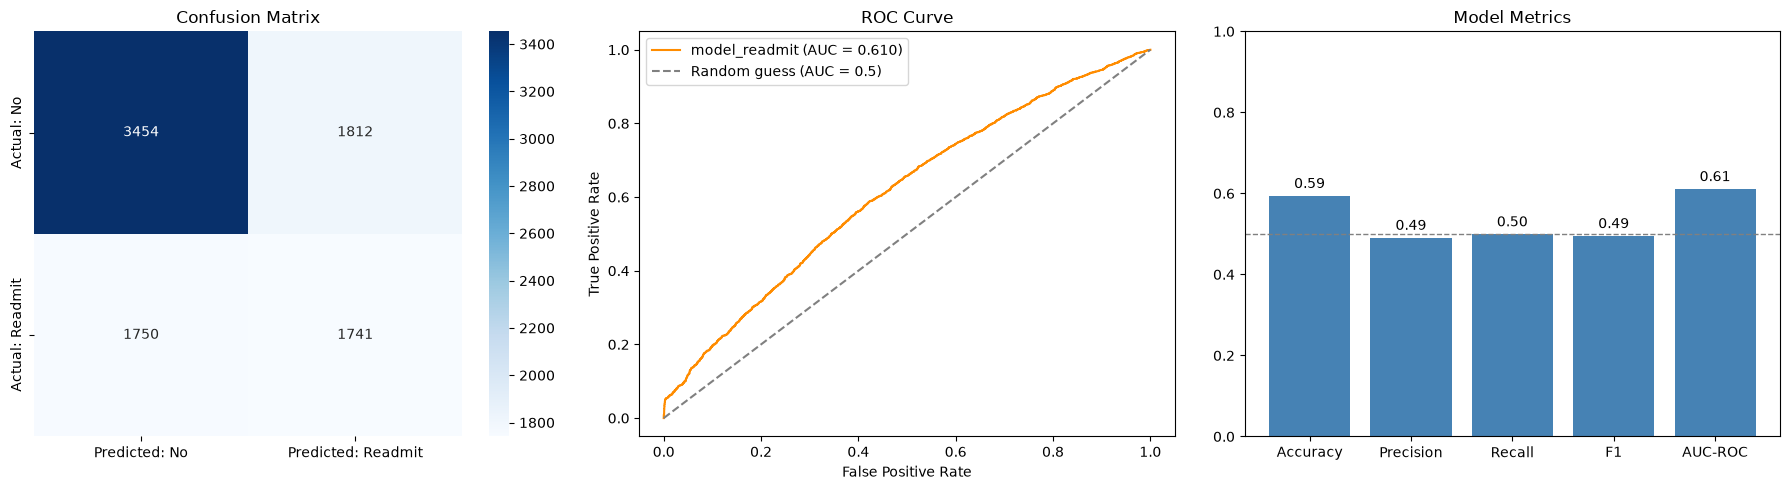

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---- 1. Confusion matrix heatmap ----
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Readmit'],
    yticklabels=['Actual: No', 'Actual: Readmit'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix')

# ---- 2. ROC curve ----
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, label=f'model_readmit (AUC = {auc:.3f})', color='darkorange')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random guess (AUC = 0.5)')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

# ---- 3. Metrics bar chart ----
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1, 'AUC-ROC': auc}
bars = axes[2].bar(metrics.keys(), metrics.values(), color='steelblue')
axes[2].set_ylim(0, 1)
axes[2].set_title('Model Metrics')
axes[2].axhline(0.5, linestyle='--', color='gray', linewidth=1)  # reference line for "coin flip"
for bar in bars:
    height = bar.get_height()
    axes[2].text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', ha='center')

plt.tight_layout()
plt.show()

Accuracy:  0.590
Precision: 0.487
Recall:    0.503
F1:        0.495
AUC-ROC:   0.609


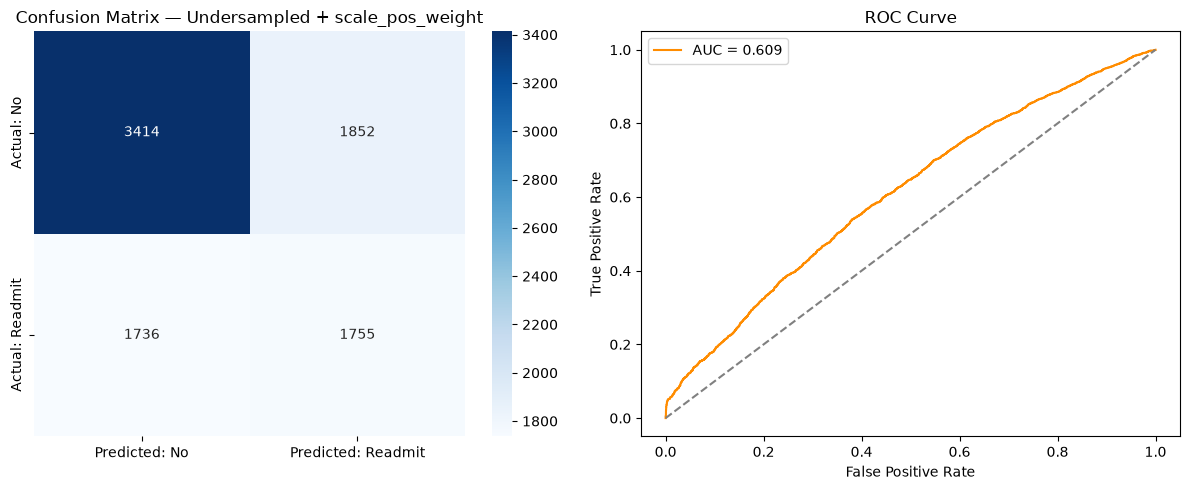

In [11]:
import pandas as pd
import numpy as np

MIMIC_ROOT = 'E:/MedAgent/data/raw/physionet.org/files/mimiciv/3.1'

# ---- load raw tables ----
admissions = pd.read_csv(f'{MIMIC_ROOT}/hosp/admissions.csv.gz')
patients = pd.read_csv(f'{MIMIC_ROOT}/hosp/patients.csv.gz')
icustays = pd.read_csv(f'{MIMIC_ROOT}/icu/icustays.csv.gz')
diagnoses = pd.read_csv(f'{MIMIC_ROOT}/hosp/diagnoses_icd.csv.gz')

# ---- base merge ----
df = icustays.merge(admissions, on=['subject_id', 'hadm_id'], how='inner')
df = df.merge(patients, on='subject_id', how='inner')

# ---- race_simplified ----
def simplify_race(race):
    race = race.upper()
    if 'WHITE' in race:
        return 'White'
    elif 'BLACK' in race:
        return 'Black'
    elif 'ASIAN' in race:
        return 'Asian'
    elif 'HISPANIC' in race or 'LATINO' in race:
        return 'Hispanic/Latino'
    elif 'SOUTH AMERICAN' in race:
        return 'Hispanic/Latino'
    elif 'AMERICAN INDIAN' in race or 'ALASKA NATIVE' in race:
        return 'American Indian/Alaska Native'
    elif 'NATIVE HAWAIIAN' in race or 'PACIFIC ISLANDER' in race:
        return 'Native Hawaiian/Pacific Islander'
    elif 'PORTUGUESE' in race:
        return 'White'
    elif 'MULTIPLE RACE' in race:
        return 'Multiple Race/Ethnicity'
    elif race in ('UNKNOWN', 'UNABLE TO OBTAIN', 'PATIENT DECLINED TO ANSWER'):
        return 'Unknown/Declined'
    else:
        return 'Other'

df['race_simplified'] = df['race'].apply(simplify_race)

# ---- one-hot encode categoricals ----
col = ['admission_type', 'admission_location', 'insurance', 'marital_status', 'race_simplified', 'first_careunit']
df = pd.get_dummies(df, columns=col, drop_first=True)

# ---- derived features ----
df['admittime'] = pd.to_datetime(df['admittime'])
df['edregtime'] = pd.to_datetime(df['edregtime'])
df['edouttime'] = pd.to_datetime(df['edouttime'])

df['gender_binary'] = (df['gender'] == 'M').astype(int)
df['age_at_admission'] = df['anchor_age'] + (df['admittime'].dt.year - df['anchor_year'])
df['admit_hour'] = df['admittime'].dt.hour
df['admit_dayofweek'] = df['admittime'].dt.dayofweek
df['ed_duration_hours'] = (df['edouttime'] - df['edregtime']).dt.total_seconds() / 3600

dx_count = diagnoses.groupby('hadm_id').size().reset_index(name='num_diagnoses')
df = df.drop(columns=['num_diagnoses'], errors='ignore')
df = df.merge(dx_count, on='hadm_id', how='left')
df['num_diagnoses'] = df['num_diagnoses'].fillna(0).astype(int)

# ---- readmit_30d target ----
admissions_sorted = admissions.sort_values(['subject_id', 'admittime']).copy()
admissions_sorted['admittime'] = pd.to_datetime(admissions_sorted['admittime'])
admissions_sorted['dischtime'] = pd.to_datetime(admissions_sorted['dischtime'])
admissions_sorted['next_admittime'] = admissions_sorted.groupby('subject_id')['admittime'].shift(-1)
admissions_sorted['days_to_next_admit'] = (admissions_sorted['next_admittime'] - admissions_sorted['dischtime']).dt.total_seconds() / 86400

admissions_sorted['readmit_30d'] = (
    (admissions_sorted['days_to_next_admit'] >= 0) &
    (admissions_sorted['days_to_next_admit'] <= 30)
).astype('Int64')
admissions_sorted.loc[admissions_sorted['days_to_next_admit'].isna(), 'readmit_30d'] = pd.NA

df = df.drop(columns=['readmit_30d'], errors='ignore')
df = df.merge(admissions_sorted[['hadm_id', 'readmit_30d']], on='hadm_id', how='left')

# ---- drop redundant columns ----
redundant_cols = ['race', 'gender', 'anchor_age', 'anchor_year', 'edregtime', 'edouttime', 'admittime']
df = df.drop(columns=redundant_cols)

# ---- drop leakage/ID columns -> model_df ----
leakage_and_id_cols = [
    'subject_id', 'hadm_id', 'stay_id', 'admit_provider_id',
    'last_careunit', 'intime', 'outtime', 'dischtime', 'deathtime',
    'discharge_location', 'hospital_expire_flag', 'dod',
    'language', 'anchor_year_group',
]
model_df = df.drop(columns=leakage_and_id_cols, errors='ignore')

print("model_df shape:", model_df.shape)

model_df shape: (94458, 57)


In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Drop readmit_30d — that's the OTHER model's target, not a feature for LOS
model_df_los = model_df.drop(columns=['readmit_30d'], errors='ignore')

# Drop rows with unusable los (NaN or infinite)
bad_mask = model_df_los['los'].isna() | np.isinf(model_df_los['los'])
model_df_los = model_df_los[~bad_mask]

X = model_df_los.drop(columns=['los'])
y = model_df_los['los']

# Patient-level split so no patient appears in both train and test
groups = df.loc[model_df_los.index, 'subject_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# Log-transform target — los is right-skewed
y_train_log = np.log(y_train)

xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_model.fit(X_train, y_train_log)

y_pred = np.clip(np.exp(xgb_model.predict(X_test)), 0, None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"XGBoost — MAE: {mae:.2f} days | RMSE: {rmse:.2f} days | R²: {r2:.4f}")

XGBoost — MAE: 2.37 days | RMSE: 5.36 days | R²: 0.0725


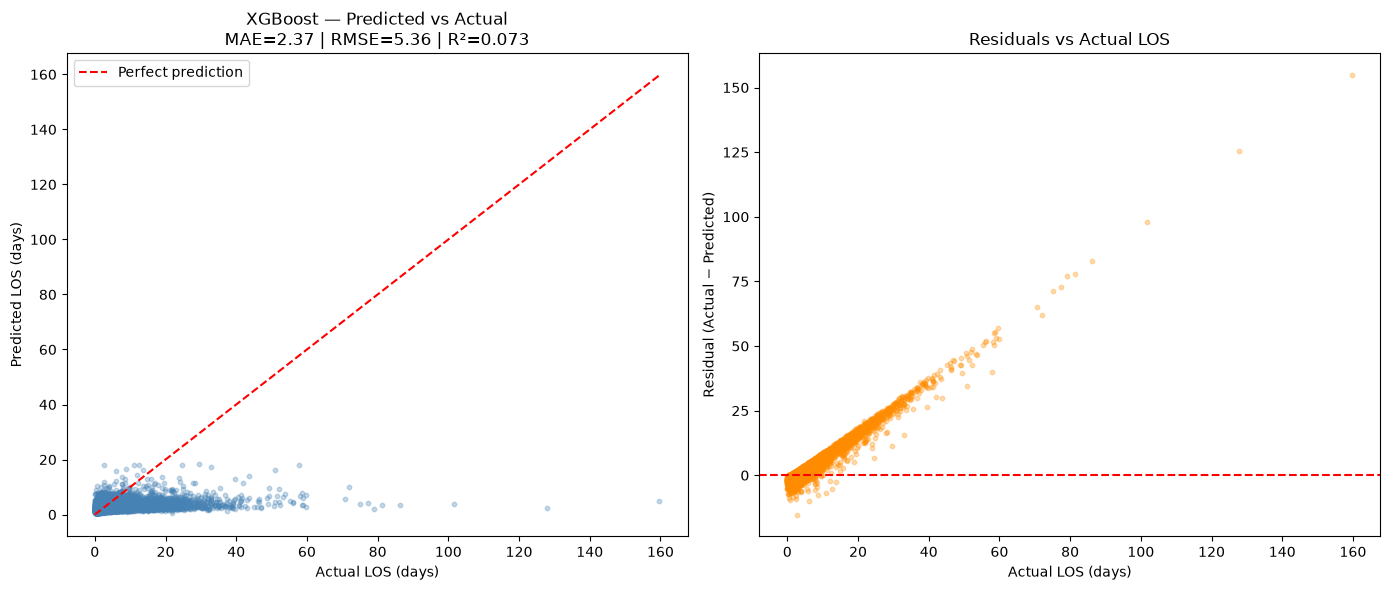

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ---- 1. Predicted vs Actual ----
axes[0].scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual LOS (days)')
axes[0].set_ylabel('Predicted LOS (days)')
axes[0].set_title(f'XGBoost — Predicted vs Actual\nMAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.3f}')
axes[0].legend()

# ---- 2. Residuals (error) vs Actual ----
residuals = y_test - y_pred
axes[1].scatter(y_test, residuals, alpha=0.3, s=10, color='darkorange')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Actual LOS (days)')
axes[1].set_ylabel('Residual (Actual − Predicted)')
axes[1].set_title('Residuals vs Actual LOS')

plt.tight_layout()
plt.show()

In [14]:
import pandas as pd
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
HOSP = MIMIC_ROOT / "hosp"
ICU = MIMIC_ROOT / "icu"

def inspect_all_csvs(folder, label):
    files = sorted(folder.glob("*.csv")) + sorted(folder.glob("*.csv.gz"))
    for file in files:
        try:
            # nrows=1 is fast even on huge files — it stops reading after the first row
            df_sample = pd.read_csv(file, nrows=1, compression="gzip" if file.suffix == ".gz" or file.name.endswith(".csv") else "infer")
            print(f"\n=== [{label}] {file.name} ===")
            print(f"Columns ({len(df_sample.columns)}):")
            print(list(df_sample.columns))
            print("First row:")
            print(df_sample.iloc[0].to_dict())
        except Exception as e:
            print(f"\n=== [{label}] {file.name} — FAILED: {e} ===")

inspect_all_csvs(HOSP, "hosp")
inspect_all_csvs(ICU, "icu")


=== [hosp] admissions.csv.gz ===
Columns (16):
['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime', 'admission_type', 'admit_provider_id', 'admission_location', 'discharge_location', 'insurance', 'language', 'marital_status', 'race', 'edregtime', 'edouttime', 'hospital_expire_flag']
First row:
{'subject_id': 10000032, 'hadm_id': 22595853, 'admittime': '2180-05-06 22:23:00', 'dischtime': '2180-05-07 17:15:00', 'deathtime': nan, 'admission_type': 'URGENT', 'admit_provider_id': 'P49AFC', 'admission_location': 'TRANSFER FROM HOSPITAL', 'discharge_location': 'HOME', 'insurance': 'Medicaid', 'language': 'English', 'marital_status': 'WIDOWED', 'race': 'WHITE', 'edregtime': '2180-05-06 19:17:00', 'edouttime': '2180-05-06 23:30:00', 'hospital_expire_flag': 0}

=== [hosp] d_hcpcs.csv.gz ===
Columns (4):
['code', 'category', 'long_description', 'short_description']
First row:
{'code': 0, 'category': nan, 'long_description': nan, 'short_description': 'Invalid Code'}

=== [hosp] d_icd_

In [15]:
import pandas as pd
import numpy as np
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
HOSP = MIMIC_ROOT / "hosp"
ICU = MIMIC_ROOT / "icu"

def load(table, folder):
    candidates = list(folder.glob(f"{table}.csv")) + list(folder.glob(f"{table}.csv.gz"))
    return pd.read_csv(candidates[0], compression="gzip")

# ============================================================
# 1. BASE COHORT — one row per ICU stay
# ============================================================
icustays = load("icustays", ICU)
icustays["intime"] = pd.to_datetime(icustays["intime"])
icustays["outtime"] = pd.to_datetime(icustays["outtime"])

df_experiment = icustays[[
    "subject_id", "hadm_id", "stay_id",
    "first_careunit", "last_careunit", "intime", "outtime", "los"
]].copy()

# ============================================================
# 2. DEMOGRAPHICS + ADMISSION FEATURES
# ============================================================
patients = load("patients", HOSP)
df_experiment = df_experiment.merge(patients[["subject_id", "gender", "anchor_age"]], on="subject_id", how="left")

admissions = load("admissions", HOSP)
for col in ["admittime", "dischtime", "edregtime", "edouttime"]:
    admissions[col] = pd.to_datetime(admissions[col])

admissions["hosp_los_days"] = (admissions["dischtime"] - admissions["admittime"]).dt.total_seconds() / 86400
admissions["came_through_ed"] = admissions["edregtime"].notna().astype(int)
admissions["ed_los_hours"] = (admissions["edouttime"] - admissions["edregtime"]).dt.total_seconds() / 3600

adm_features = admissions[[
    "hadm_id", "admission_type", "admission_location", "discharge_location",
    "insurance", "marital_status", "language", "hosp_los_days",
    "came_through_ed", "ed_los_hours", "hospital_expire_flag"
]]
df_experiment = df_experiment.merge(adm_features, on="hadm_id", how="left")

# ============================================================
# 3. COMPLEXITY/BURDEN PROXIES — small tables, aggregate then merge
# ============================================================
diagnoses = load("diagnoses_icd", HOSP)
num_diagnoses = diagnoses.groupby("hadm_id").size().rename("num_diagnoses").reset_index()
df_experiment = df_experiment.merge(num_diagnoses, on="hadm_id", how="left")

procedures = load("procedures_icd", HOSP)
num_procedures = procedures.groupby("hadm_id").size().rename("num_procedures").reset_index()
df_experiment = df_experiment.merge(num_procedures, on="hadm_id", how="left")

transfers = load("transfers", HOSP)
num_transfers = transfers.groupby("hadm_id").size().rename("num_transfers").reset_index()
df_experiment = df_experiment.merge(num_transfers, on="hadm_id", how="left")

prescriptions = load("prescriptions", HOSP)
num_distinct_meds = prescriptions.groupby("hadm_id")["drug"].nunique().rename("num_distinct_meds").reset_index()
df_experiment = df_experiment.merge(num_distinct_meds, on="hadm_id", how="left")

services = load("services", HOSP)
first_service = (
    services.sort_values("transfertime")
    .groupby("hadm_id")["curr_service"].first()
    .rename("admitting_service").reset_index()
)
df_experiment = df_experiment.merge(first_service, on="hadm_id", how="left")

# DRG severity/mortality scores — hospital's own severity-of-illness estimate
drgcodes = load("drgcodes", HOSP)
drg_apr = drgcodes[drgcodes["drg_type"] == "APR"]  # APR-DRG carries severity/mortality scores
drg_scores = (
    drg_apr.groupby("hadm_id")[["drg_severity", "drg_mortality"]]
    .mean()  # mean in case of duplicate rows per admission
    .reset_index()
)
df_experiment = df_experiment.merge(drg_scores, on="hadm_id", how="left")

# Microbiology test count — proxy for suspected infection workup
microbio = load("microbiologyevents", HOSP)
num_micro_tests = microbio.groupby("hadm_id").size().rename("num_micro_tests").reset_index()
df_experiment = df_experiment.merge(num_micro_tests, on="hadm_id", how="left")

print("After small-table merges:", df_experiment.shape)

# ============================================================
# 4. VITALS — chartevents, chunked + filtered to first 24h
# ============================================================
VITAL_ITEMIDS = {
    220045: "heart_rate",
    220210: "resp_rate",
    220277: "spo2",
    220179: "sbp_noninvasive",
    220180: "dbp_noninvasive",
    223761: "temp_f",
    223900: "gcs_verbal",
}

intime_lookup = icustays.set_index("stay_id")["intime"]

chart_chunks = []
usecols = ["stay_id", "charttime", "itemid", "valuenum"]
for chunk in pd.read_csv(ICU / "chartevents.csv.gz", compression="gzip",
                          usecols=usecols, chunksize=2_000_000):
    chunk = chunk[chunk["itemid"].isin(VITAL_ITEMIDS.keys())]
    if chunk.empty:
        continue
    chunk["charttime"] = pd.to_datetime(chunk["charttime"])
    chunk["intime"] = chunk["stay_id"].map(intime_lookup)
    chunk = chunk[(chunk["charttime"] >= chunk["intime"]) &
                  (chunk["charttime"] <= chunk["intime"] + pd.Timedelta(hours=24))]
    chart_chunks.append(chunk[["stay_id", "itemid", "valuenum"]])

chartevents_24h = pd.concat(chart_chunks, ignore_index=True)
vitals_wide = (
    chartevents_24h.groupby(["stay_id", "itemid"])["valuenum"].mean()
    .unstack("itemid")
    .rename(columns=VITAL_ITEMIDS)
    .add_prefix("mean_")
    .reset_index()
)
df_experiment = df_experiment.merge(vitals_wide, on="stay_id", how="left")
print("After vitals merge:", df_experiment.shape)

# ============================================================
# 5. LABS — labevents, chunked + filtered to first 24h (relative to hospital admission)
# ============================================================
LAB_ITEMIDS = {
    50912: "creatinine",
    51006: "bun",
    51301: "wbc",
    51222: "hemoglobin",
    51265: "platelet",
    50983: "sodium",
    50971: "potassium",
    50882: "bicarbonate",
    50931: "glucose",
}

admittime_lookup = admissions.set_index("hadm_id")["admittime"]

lab_chunks = []
usecols = ["hadm_id", "charttime", "itemid", "valuenum"]
for chunk in pd.read_csv(HOSP / "labevents.csv.gz", compression="gzip",
                          usecols=usecols, chunksize=2_000_000):
    chunk = chunk[chunk["itemid"].isin(LAB_ITEMIDS.keys()) & chunk["hadm_id"].notna()]
    if chunk.empty:
        continue
    chunk["charttime"] = pd.to_datetime(chunk["charttime"])
    chunk["admittime"] = chunk["hadm_id"].map(admittime_lookup)
    chunk = chunk[(chunk["charttime"] >= chunk["admittime"]) &
                  (chunk["charttime"] <= chunk["admittime"] + pd.Timedelta(hours=24))]
    lab_chunks.append(chunk[["hadm_id", "itemid", "valuenum"]])

labevents_24h = pd.concat(lab_chunks, ignore_index=True)
labs_wide = (
    labevents_24h.groupby(["hadm_id", "itemid"])["valuenum"].mean()
    .unstack("itemid")
    .rename(columns=LAB_ITEMIDS)
    .add_prefix("mean_")
    .reset_index()
)
df_experiment = df_experiment.merge(labs_wide, on="hadm_id", how="left")
print("After labs merge:", df_experiment.shape)

# ============================================================
# 6. CLEANING
# ============================================================
# Drop rows with unusable target
bad_los = df_experiment["los"].isna() | np.isinf(df_experiment["los"])
df_experiment = df_experiment[~bad_los]

# Count-based features: missing means "zero events", not "unknown" -> fill 0
count_cols = ["num_diagnoses", "num_procedures", "num_transfers", "num_distinct_meds", "num_micro_tests"]
for col in count_cols:
    df_experiment[col] = df_experiment[col].fillna(0)

# Vitals/labs: missing means "never measured", not "zero" -> impute with column median
vital_lab_cols = [c for c in df_experiment.columns if c.startswith("mean_")]
for col in vital_lab_cols:
    df_experiment[col] = df_experiment[col].fillna(df_experiment[col].median())

# DRG scores: missing (no APR-DRG record) -> median fill, same reasoning
for col in ["drg_severity", "drg_mortality"]:
    df_experiment[col] = df_experiment[col].fillna(df_experiment[col].median())

print("Final df_experiment shape:", df_experiment.shape)
print("Remaining NaNs:\n", df_experiment.isna().sum()[df_experiment.isna().sum() > 0])

C:\Users\icsti\AppData\Local\Temp\ipykernel_19948\1220805215.py:11: DtypeWarning: Columns (0: gsn) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(candidates[0], compression="gzip")
C:\Users\icsti\AppData\Local\Temp\ipykernel_19948\1220805215.py:11: DtypeWarning: Columns (0: quantity) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(candidates[0], compression="gzip")


After small-table merges: (94458, 28)
After vitals merge: (94458, 35)
After labs merge: (94458, 44)
Final df_experiment shape: (94444, 44)
Remaining NaNs:
 discharge_location      848
insurance              1523
marital_status         7756
language                396
ed_los_hours          32321
admitting_service         2
dtype: int64


In [18]:
print(df_experiment.shape)
df_experiment.head()

(94444, 44)


,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,admission_type,admission_location,discharge_location,insurance,marital_status,language,hosp_los_days,came_through_ed,ed_los_hours,hospital_expire_flag,num_diagnoses,num_procedures,num_transfers,num_distinct_meds,admitting_service,drg_severity,drg_mortality,num_micro_tests,mean_heart_rate,mean_sbp_noninvasive,mean_dbp_noninvasive,mean_resp_rate,mean_spo2,mean_temp_f,mean_gcs_verbal,mean_bicarbonate,mean_creatinine,mean_glucose,mean_potassium,mean_sodium,mean_bun,mean_hemoglobin,mean_platelet,mean_wbc
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,F,52,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,WIDOWED,English,2.222222,1,8.100000,0,13.0,0.0,6,17.0,MED,3.0,3.0,2.0,96.500000,88.900000,54.100000,20.700000,96.300000,98.966667,4.666667,22.5,0.45,111.0,4.85,131.0,30.5,11.9,94.0,4.1
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,F,86,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,WIDOWED,English,9.821528,1,7.933333,0,22.0,1.0,4,37.0,MED,4.0,4.0,5.0,79.800000,108.958333,50.666667,21.840000,94.916667,97.950000,4.500000,26.0,0.90,77.0,4.40,137.0,21.0,9.5,199.0,7.5
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,F,73,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,MARRIED,English,5.806944,1,2.283333,0,15.0,7.0,4,34.0,MED,3.0,4.0,1.0,73.636364,142.454545,83.272727,20.545455,98.909091,98.133333,5.000000,23.0,2.20,144.0,4.20,139.0,38.0,10.1,217.0,5.4
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,F,55,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,MARRIED,Other,6.794444,1,7.766667,0,10.0,3.0,6,23.0,NMED,3.0,4.0,13.0,93.200000,135.320000,80.960000,21.320000,96.080000,99.062500,5.000000,23.5,1.00,124.0,4.10,139.0,19.0,10.8,196.0,9.8
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,F,55,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,MARRIED,Other,5.914583,0,NaN,0,7.0,1.0,5,27.0,NSURG,3.0,2.0,7.0,79.600000,115.869565,73.478261,16.640000,93.880000,98.133333,5.000000,30.0,0.50,87.0,4.10,142.0,11.0,12.5,301.0,5.4


df_clean shape: (94444, 89)
Remaining NaNs: 0
frankenstein_los — MAE: 1.81 days | RMSE: 4.16 days | R²: 0.4413


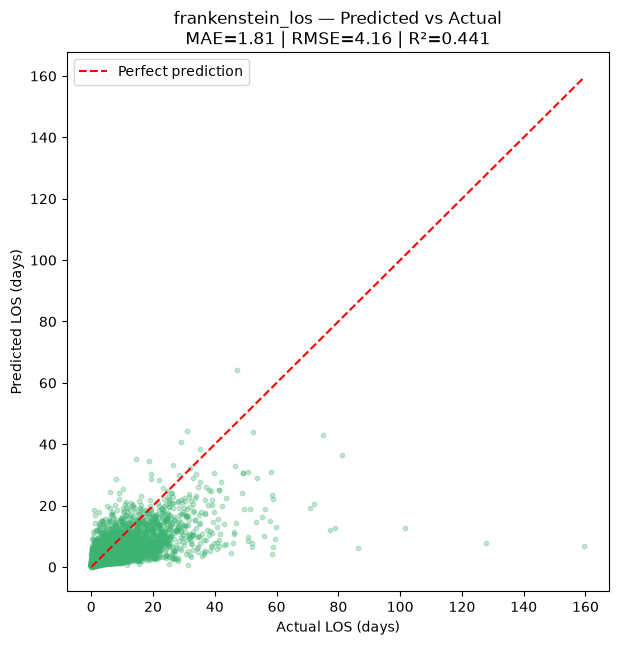

In [19]:
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. Drop leakage / redundant / ID columns
# ============================================================
drop_cols = [
    'subject_id', 'hadm_id', 'stay_id',        # IDs
    'intime', 'outtime',                        # raw timestamps, already used to compute los
    'last_careunit',                            # redundant with first_careunit (same value, one ICU stay)
    'hosp_los_days',                             # LEAKAGE — depends on dischtime, which is after outtime
    'discharge_location',                        # LEAKAGE — only known at hospital discharge
    'hospital_expire_flag',                      # LEAKAGE — outcome known only at/after discharge
    'language',                                  # excluded, same as race, pending discussion with Alexander
]
df_clean = df_experiment.drop(columns=drop_cols, errors='ignore').copy()

# ============================================================
# 2. Handle remaining NaNs
# ============================================================
# ed_los_hours is NaN specifically when came_through_ed == 0 — not missing data,
# just "no ED time to measure." Fill with 0; came_through_ed already flags the distinction.
df_clean['ed_los_hours'] = df_clean['ed_los_hours'].fillna(0)

# True missing categoricals -> explicit 'Unknown' category rather than dropping rows
for col in ['insurance', 'marital_status', 'admitting_service']:
    df_clean[col] = df_clean[col].fillna('Unknown')

# ============================================================
# 3. Encode categoricals
# ============================================================
df_clean['gender_binary'] = (df_clean['gender'] == 'M').astype(int)
df_clean = df_clean.drop(columns=['gender'])

cat_cols = ['first_careunit', 'admission_type', 'admission_location', 'insurance', 'marital_status', 'admitting_service']
df_clean = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print("df_clean shape:", df_clean.shape)
print("Remaining NaNs:", df_clean.isna().sum().sum())

# ============================================================
# 4. Patient-level train/test split
# ============================================================
X = df_clean.drop(columns=['los'])
y = df_clean['los']
groups = df_experiment.loc[df_clean.index, 'subject_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

# ============================================================
# 5. Train frankenstein_los
# ============================================================
y_train_log = np.log(y_train)

frankenstein_los = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
frankenstein_los.fit(X_train, y_train_log)

y_pred = np.clip(np.exp(frankenstein_los.predict(X_test)), 0, None)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"frankenstein_los — MAE: {mae:.2f} days | RMSE: {rmse:.2f} days | R²: {r2:.4f}")

# ============================================================
# 6. Plot: Actual vs Predicted
# ============================================================
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='mediumseagreen')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel('Actual LOS (days)')
plt.ylabel('Predicted LOS (days)')
plt.title(f'frankenstein_los — Predicted vs Actual\nMAE={mae:.2f} | RMSE={rmse:.2f} | R²={r2:.3f}')
plt.legend()
plt.show()

=== frankenstein_los metrics ===
MAE:  1.81 days
RMSE: 4.16 days
R²:   0.4413
MAPE: 72.2%

=== Baselines for comparison ===
Guessing the mean (3.61 days):   MAE = 3.01 days
Guessing the median (1.96 days): MAE = 2.57 days

=== vs. previous best (model_v3) ===
model_v3:         MAE = 2.10 days | RMSE = 4.99 | R² = 0.196 (ln scale)
frankenstein_los: MAE = 1.81 days | RMSE = 4.16 | R² = 0.4413 (raw scale)


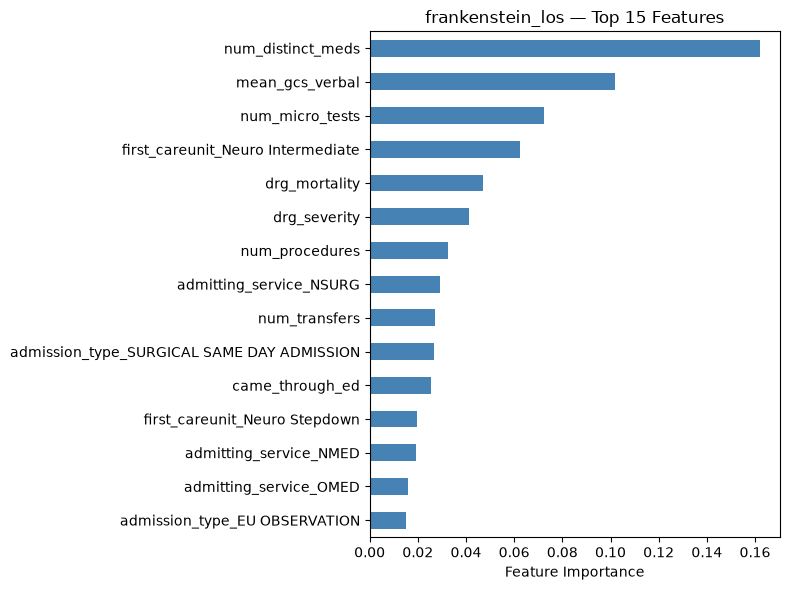


Top 15 features:
num_distinct_meds                             0.162257
mean_gcs_verbal                               0.101681
num_micro_tests                               0.072586
first_careunit_Neuro Intermediate             0.062313
drg_mortality                                 0.047196
drg_severity                                  0.041335
num_procedures                                0.032377
admitting_service_NSURG                       0.029221
num_transfers                                 0.026980
admission_type_SURGICAL SAME DAY ADMISSION    0.026838
came_through_ed                               0.025455
first_careunit_Neuro Stepdown                 0.019494
admitting_service_NMED                        0.019064
admitting_service_OMED                        0.015868
admission_type_EU OBSERVATION                 0.015017
dtype: float32


In [20]:
from sklearn.metrics import mean_absolute_percentage_error

# ============================================================
# Additional metrics for frankenstein_los
# ============================================================
mape = mean_absolute_percentage_error(y_test, y_pred)

# Baseline comparisons — guessing the mean or median LOS for every patient,
# same reference points your original model_v3 table used
baseline_mean = y_train.mean()
baseline_median = y_train.median()
mae_baseline_mean = mean_absolute_error(y_test, np.full_like(y_test, baseline_mean))
mae_baseline_median = mean_absolute_error(y_test, np.full_like(y_test, baseline_median))

print("=== frankenstein_los metrics ===")
print(f"MAE:  {mae:.2f} days")
print(f"RMSE: {rmse:.2f} days")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.1%}")
print()
print("=== Baselines for comparison ===")
print(f"Guessing the mean ({baseline_mean:.2f} days):   MAE = {mae_baseline_mean:.2f} days")
print(f"Guessing the median ({baseline_median:.2f} days): MAE = {mae_baseline_median:.2f} days")
print()
print(f"=== vs. previous best (model_v3) ===")
print(f"model_v3:         MAE = 2.10 days | RMSE = 4.99 | R² = 0.196 (ln scale)")
print(f"frankenstein_los: MAE = {mae:.2f} days | RMSE = {rmse:.2f} | R² = {r2:.4f} (raw scale)")

# ============================================================
# Feature importance — top 15
# ============================================================
importances = pd.Series(frankenstein_los.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='steelblue')
plt.xlabel('Feature Importance')
plt.title('frankenstein_los — Top 15 Features')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(top_features)

=== frankenstein_los as 'extended stay (>7d)' classifier ===
Accuracy:  0.917
Precision: 0.783
Recall:    0.427
F1:        0.553
AUC-ROC:   0.926

Actual extended-stay rate in test set: 12.1%

Confusion matrix:
[[16488   272]
 [ 1319   983]]


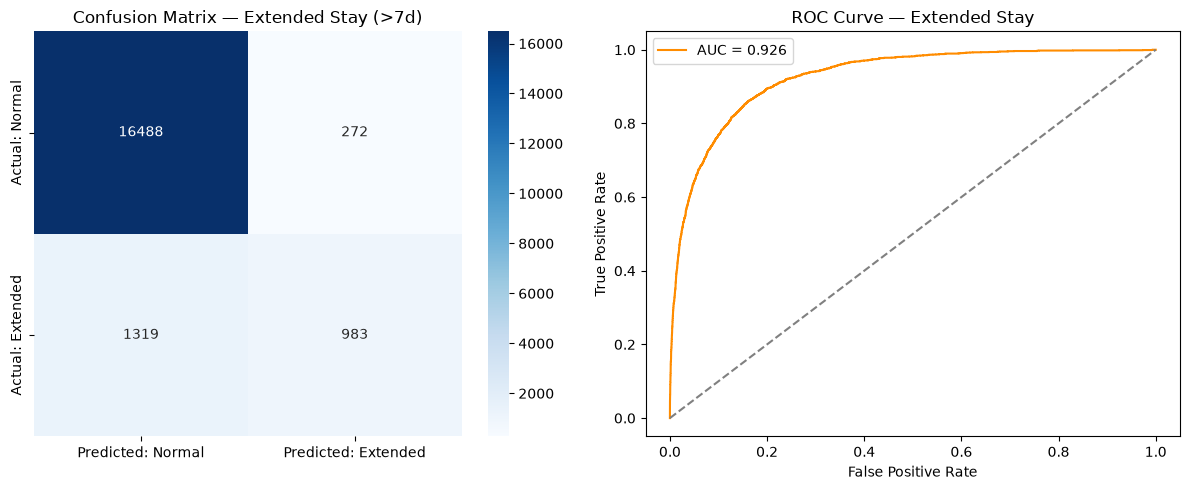

In [21]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    accuracy_score, roc_auc_score, confusion_matrix
)

# ============================================================
# Reframe as classification: "extended stay" = LOS > 7 days
# ============================================================
THRESHOLD = 7

y_test_class = (y_test > THRESHOLD).astype(int)
y_pred_class = (y_pred > THRESHOLD).astype(int)

acc = accuracy_score(y_test_class, y_pred_class)
prec = precision_score(y_test_class, y_pred_class)
rec = recall_score(y_test_class, y_pred_class)
f1 = f1_score(y_test_class, y_pred_class)
auc = roc_auc_score(y_test_class, y_pred)  # use continuous y_pred, not the thresholded version, for AUC
cm = confusion_matrix(y_test_class, y_pred_class)

print(f"=== frankenstein_los as 'extended stay (>{THRESHOLD}d)' classifier ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")
print(f"\nActual extended-stay rate in test set: {y_test_class.mean():.1%}")
print("\nConfusion matrix:")
print(cm)

# ---- Plot ----
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Normal', 'Predicted: Extended'],
    yticklabels=['Actual: Normal', 'Actual: Extended'],
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — Extended Stay (>{THRESHOLD}d)')

fpr, tpr, _ = roc_curve(y_test_class, y_pred)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve — Extended Stay')
axes[1].legend()

plt.tight_layout()
plt.show()

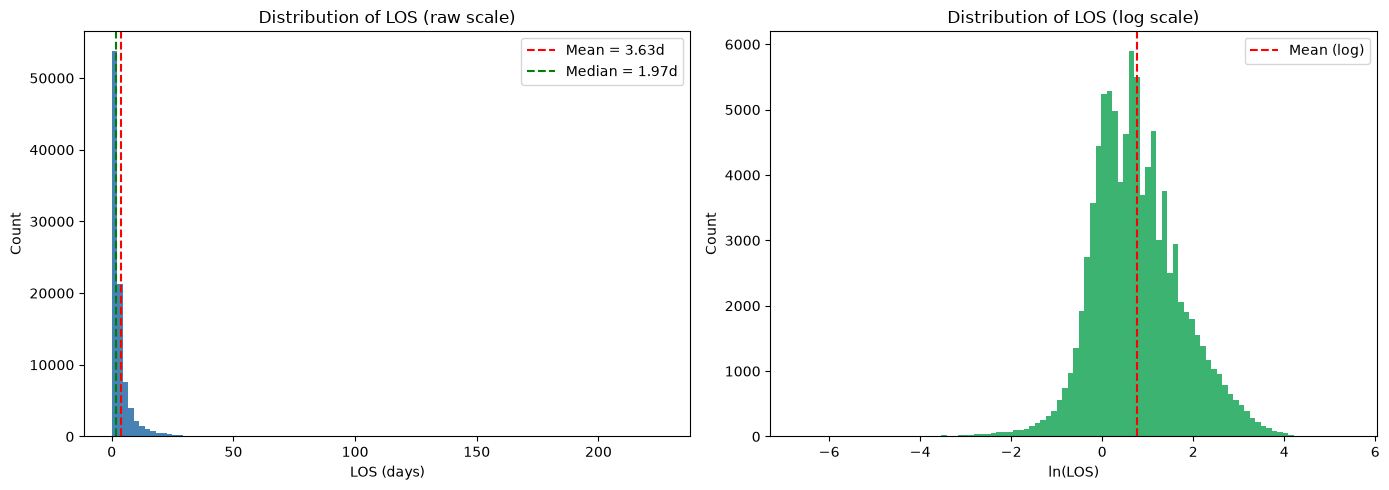

LOS summary stats:
count    94444.000000
mean         3.630025
std          5.402474
min          0.001250
25%          1.096212
50%          1.965648
75%          3.862575
max        226.403079
Name: los, dtype: float64

Skewness: 6.25


In [22]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- 1. Raw distribution ----
axes[0].hist(df_experiment['los'], bins=100, color='steelblue', edgecolor='none')
axes[0].axvline(df_experiment['los'].mean(), color='red', linestyle='--', label=f"Mean = {df_experiment['los'].mean():.2f}d")
axes[0].axvline(df_experiment['los'].median(), color='green', linestyle='--', label=f"Median = {df_experiment['los'].median():.2f}d")
axes[0].set_xlabel('LOS (days)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of LOS (raw scale)')
axes[0].legend()

# ---- 2. Log-scale distribution ----
axes[1].hist(np.log(df_experiment['los']), bins=100, color='mediumseagreen', edgecolor='none')
axes[1].axvline(np.log(df_experiment['los']).mean(), color='red', linestyle='--', label='Mean (log)')
axes[1].set_xlabel('ln(LOS)')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of LOS (log scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"LOS summary stats:")
print(df_experiment['los'].describe())
print(f"\nSkewness: {df_experiment['los'].skew():.2f}")

In [23]:
for days in [3, 5, 7, 10, 14]:
    pct = (df_experiment['los'] > days).mean()
    print(f"LOS > {days} days: {pct:.1%} of patients")

print("\nPercentile reference:")
print(df_experiment['los'].quantile([0.75, 0.80, 0.85, 0.90, 0.95]))

LOS > 3 days: 33.0% of patients
LOS > 5 days: 18.2% of patients
LOS > 7 days: 11.8% of patients
LOS > 10 days: 7.1% of patients
LOS > 14 days: 4.1% of patients

Percentile reference:
0.75     3.862575
0.80     4.656674
0.85     5.852606
0.90     7.920927
0.95    12.681538
Name: los, dtype: float64


Class balance: 11.8% extended stay

=== model_extended_stay (LOS > 7d) ===
Accuracy:  0.849
Precision: 0.437
Recall:    0.860
F1:        0.580
AUC-ROC:   0.933

Confusion matrix:
[[14209  2551]
 [  322  1980]]


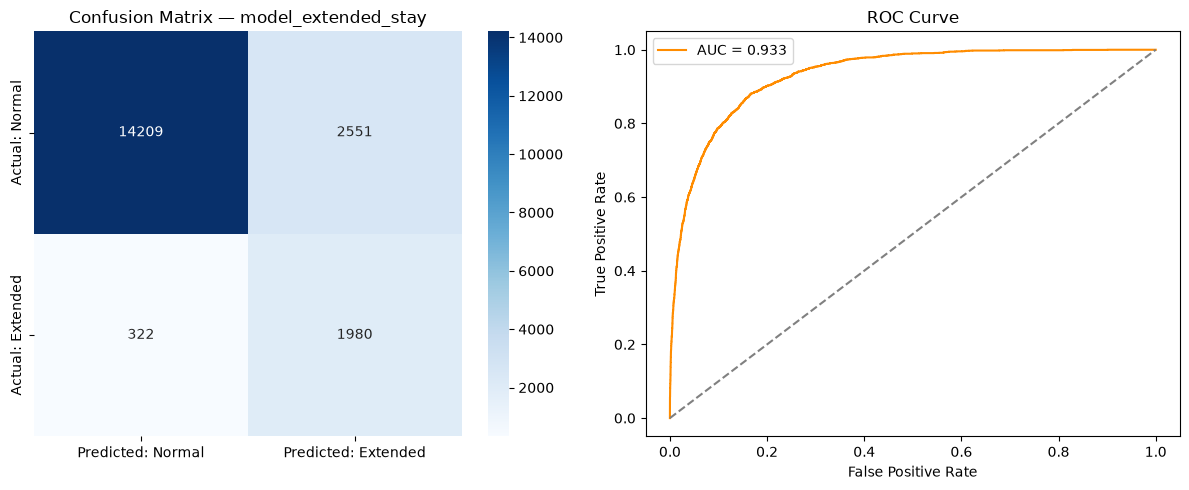

In [24]:
import xgboost as xgb
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns

THRESHOLD = 7

# ============================================================
# 1. Build the binary target
# ============================================================
df_extended = df_clean.copy()
df_extended['extended_stay'] = (df_extended['los'] > THRESHOLD).astype(int)

print(f"Class balance: {df_extended['extended_stay'].mean():.1%} extended stay")

# ============================================================
# 2. Split — los itself must NOT be a feature (that would be predicting
#    the label from a more precise version of itself)
# ============================================================
X2 = df_extended.drop(columns=['los', 'extended_stay'])
y2 = df_extended['extended_stay']
groups2 = df_experiment.loc[df_extended.index, 'subject_id']

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx2, test_idx2 = next(gss2.split(X2, y2, groups=groups2))

X2_train, X2_test = X2.iloc[train_idx2], X2.iloc[test_idx2]
y2_train, y2_test = y2.iloc[train_idx2], y2.iloc[test_idx2]

# ============================================================
# 3. Train — scale_pos_weight balances the classes, same as model_readmit
# ============================================================
scale_pos_weight = (y2_train == 0).sum() / (y2_train == 1).sum()

model_extended_stay = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=scale_pos_weight, random_state=42
)
model_extended_stay.fit(X2_train, y2_train)

# ============================================================
# 4. Metrics
# ============================================================
y2_pred = model_extended_stay.predict(X2_test)
y2_prob = model_extended_stay.predict_proba(X2_test)[:, 1]

acc = accuracy_score(y2_test, y2_pred)
prec = precision_score(y2_test, y2_pred)
rec = recall_score(y2_test, y2_pred)
f1 = f1_score(y2_test, y2_pred)
auc = roc_auc_score(y2_test, y2_prob)
cm = confusion_matrix(y2_test, y2_pred)

print(f"\n=== model_extended_stay (LOS > {THRESHOLD}d) ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")
print("\nConfusion matrix:")
print(cm)

# ============================================================
# 5. Plot
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: Normal', 'Predicted: Extended'],
    yticklabels=['Actual: Normal', 'Actual: Extended'],
    ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix — model_extended_stay')

fpr, tpr, _ = roc_curve(y2_test, y2_prob)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

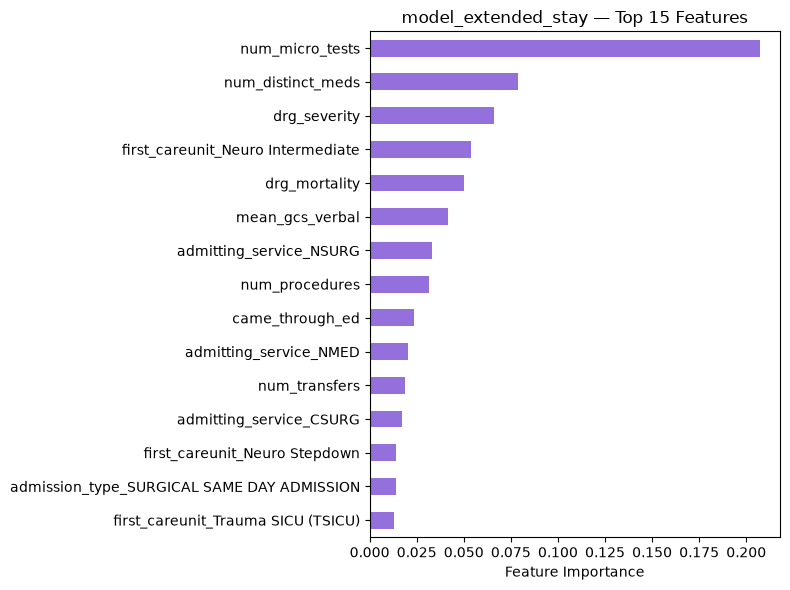

Top 15 features:
num_micro_tests                               0.207538
num_distinct_meds                             0.078834
drg_severity                                  0.065777
first_careunit_Neuro Intermediate             0.054010
drg_mortality                                 0.050056
mean_gcs_verbal                               0.041552
admitting_service_NSURG                       0.033231
num_procedures                                0.031314
came_through_ed                               0.023532
admitting_service_NMED                        0.020478
num_transfers                                 0.018619
admitting_service_CSURG                       0.017396
first_careunit_Neuro Stepdown                 0.014194
admission_type_SURGICAL SAME DAY ADMISSION    0.013846
first_careunit_Trauma SICU (TSICU)            0.013084
dtype: float32


In [31]:
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model_extended_stay.feature_importances_, index=X2_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='mediumpurple')
plt.xlabel('Feature Importance')
plt.title('model_extended_stay — Top 15 Features')
plt.tight_layout()
plt.show()

print("Top 15 features:")
print(top_features)

In [ ]:
model_extended_stay.feature_importances_

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [26]:
import pandas as pd
import numpy as np
from pathlib import Path

MIMIC_ROOT = Path(r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1")
HOSP = MIMIC_ROOT / "hosp"
ICU = MIMIC_ROOT / "icu"

def load(table, folder):
    candidates = list(folder.glob(f"{table}.csv")) + list(folder.glob(f"{table}.csv.gz"))
    return pd.read_csv(candidates[0], compression="gzip")

# ============================================================
# 1. BASE COHORT — one row per ICU stay
# ============================================================
icustays = load("icustays", ICU)
icustays["intime"] = pd.to_datetime(icustays["intime"])
icustays["outtime"] = pd.to_datetime(icustays["outtime"])

df_readmit = icustays[[
    "subject_id", "hadm_id", "stay_id",
    "first_careunit", "last_careunit", "intime", "outtime", "los"
]].copy()

# ============================================================
# 2. DEMOGRAPHICS + ADMISSION FEATURES
# ============================================================
patients = load("patients", HOSP)
df_readmit = df_readmit.merge(patients[["subject_id", "gender", "anchor_age"]], on="subject_id", how="left")

admissions = load("admissions", HOSP)
for col in ["admittime", "dischtime", "edregtime", "edouttime"]:
    admissions[col] = pd.to_datetime(admissions[col])

admissions["hosp_los_days"] = (admissions["dischtime"] - admissions["admittime"]).dt.total_seconds() / 86400
admissions["came_through_ed"] = admissions["edregtime"].notna().astype(int)
admissions["ed_los_hours"] = (admissions["edouttime"] - admissions["edregtime"]).dt.total_seconds() / 3600

adm_features = admissions[[
    "hadm_id", "admission_type", "admission_location", "discharge_location",
    "insurance", "marital_status", "language", "hosp_los_days",
    "came_through_ed", "ed_los_hours", "hospital_expire_flag"
]]
df_readmit = df_readmit.merge(adm_features, on="hadm_id", how="left")

# ============================================================
# 3. COMPLEXITY/BURDEN PROXIES
# ============================================================
diagnoses = load("diagnoses_icd", HOSP)
num_diagnoses = diagnoses.groupby("hadm_id").size().rename("num_diagnoses").reset_index()
df_readmit = df_readmit.merge(num_diagnoses, on="hadm_id", how="left")

procedures = load("procedures_icd", HOSP)
num_procedures = procedures.groupby("hadm_id").size().rename("num_procedures").reset_index()
df_readmit = df_readmit.merge(num_procedures, on="hadm_id", how="left")

transfers = load("transfers", HOSP)
num_transfers = transfers.groupby("hadm_id").size().rename("num_transfers").reset_index()
df_readmit = df_readmit.merge(num_transfers, on="hadm_id", how="left")

prescriptions = load("prescriptions", HOSP)
num_distinct_meds = prescriptions.groupby("hadm_id")["drug"].nunique().rename("num_distinct_meds").reset_index()
df_readmit = df_readmit.merge(num_distinct_meds, on="hadm_id", how="left")

services = load("services", HOSP)
first_service = (
    services.sort_values("transfertime")
    .groupby("hadm_id")["curr_service"].first()
    .rename("admitting_service").reset_index()
)
df_readmit = df_readmit.merge(first_service, on="hadm_id", how="left")

drgcodes = load("drgcodes", HOSP)
drg_apr = drgcodes[drgcodes["drg_type"] == "APR"]
drg_scores = drg_apr.groupby("hadm_id")[["drg_severity", "drg_mortality"]].mean().reset_index()
df_readmit = df_readmit.merge(drg_scores, on="hadm_id", how="left")

microbio = load("microbiologyevents", HOSP)
num_micro_tests = microbio.groupby("hadm_id").size().rename("num_micro_tests").reset_index()
df_readmit = df_readmit.merge(num_micro_tests, on="hadm_id", how="left")

print("After small-table merges:", df_readmit.shape)

# ============================================================
# 4. VITALS — chartevents, chunked + filtered to first 24h
# ============================================================
VITAL_ITEMIDS = {
    220045: "heart_rate", 220210: "resp_rate", 220277: "spo2",
    220179: "sbp_noninvasive", 220180: "dbp_noninvasive",
    223761: "temp_f", 223900: "gcs_verbal",
}
intime_lookup = icustays.set_index("stay_id")["intime"]

chart_chunks = []
for chunk in pd.read_csv(ICU / "chartevents.csv.gz", compression="gzip",
                          usecols=["stay_id", "charttime", "itemid", "valuenum"],
                          chunksize=2_000_000):
    chunk = chunk[chunk["itemid"].isin(VITAL_ITEMIDS.keys())]
    if chunk.empty:
        continue
    chunk["charttime"] = pd.to_datetime(chunk["charttime"])
    chunk["intime"] = chunk["stay_id"].map(intime_lookup)
    chunk = chunk[(chunk["charttime"] >= chunk["intime"]) &
                  (chunk["charttime"] <= chunk["intime"] + pd.Timedelta(hours=24))]
    chart_chunks.append(chunk[["stay_id", "itemid", "valuenum"]])

chartevents_24h = pd.concat(chart_chunks, ignore_index=True)
vitals_wide = (
    chartevents_24h.groupby(["stay_id", "itemid"])["valuenum"].mean()
    .unstack("itemid").rename(columns=VITAL_ITEMIDS).add_prefix("mean_").reset_index()
)
df_readmit = df_readmit.merge(vitals_wide, on="stay_id", how="left")
print("After vitals merge:", df_readmit.shape)

# ============================================================
# 5. LABS — labevents, chunked + filtered to first 24h
# ============================================================
LAB_ITEMIDS = {
    50912: "creatinine", 51006: "bun", 51301: "wbc", 51222: "hemoglobin",
    51265: "platelet", 50983: "sodium", 50971: "potassium",
    50882: "bicarbonate", 50931: "glucose",
}
admittime_lookup = admissions.set_index("hadm_id")["admittime"]

lab_chunks = []
for chunk in pd.read_csv(HOSP / "labevents.csv.gz", compression="gzip",
                          usecols=["hadm_id", "charttime", "itemid", "valuenum"],
                          chunksize=2_000_000):
    chunk = chunk[chunk["itemid"].isin(LAB_ITEMIDS.keys()) & chunk["hadm_id"].notna()]
    if chunk.empty:
        continue
    chunk["charttime"] = pd.to_datetime(chunk["charttime"])
    chunk["admittime"] = chunk["hadm_id"].map(admittime_lookup)
    chunk = chunk[(chunk["charttime"] >= chunk["admittime"]) &
                  (chunk["charttime"] <= chunk["admittime"] + pd.Timedelta(hours=24))]
    lab_chunks.append(chunk[["hadm_id", "itemid", "valuenum"]])

labevents_24h = pd.concat(lab_chunks, ignore_index=True)
labs_wide = (
    labevents_24h.groupby(["hadm_id", "itemid"])["valuenum"].mean()
    .unstack("itemid").rename(columns=LAB_ITEMIDS).add_prefix("mean_").reset_index()
)
df_readmit = df_readmit.merge(labs_wide, on="hadm_id", how="left")
print("After labs merge:", df_readmit.shape)

# ============================================================
# 6. TARGET — readmit_30d
# ============================================================
admissions_sorted = admissions.sort_values(["subject_id", "admittime"]).copy()
admissions_sorted["next_admittime"] = admissions_sorted.groupby("subject_id")["admittime"].shift(-1)
admissions_sorted["days_to_next_admit"] = (
    (admissions_sorted["next_admittime"] - admissions_sorted["dischtime"]).dt.total_seconds() / 86400
)
admissions_sorted["readmit_30d"] = (
    (admissions_sorted["days_to_next_admit"] >= 0) &
    (admissions_sorted["days_to_next_admit"] <= 30)
).astype("Int64")
admissions_sorted.loc[admissions_sorted["days_to_next_admit"].isna(), "readmit_30d"] = pd.NA

df_readmit = df_readmit.merge(admissions_sorted[["hadm_id", "readmit_30d"]], on="hadm_id", how="left")

# ============================================================
# 7. CLEANING
# ============================================================
count_cols = ["num_diagnoses", "num_procedures", "num_transfers", "num_distinct_meds", "num_micro_tests"]
for col in count_cols:
    df_readmit[col] = df_readmit[col].fillna(0)

vital_lab_cols = [c for c in df_readmit.columns if c.startswith("mean_")]
for col in vital_lab_cols:
    df_readmit[col] = df_readmit[col].fillna(df_readmit[col].median())

for col in ["drg_severity", "drg_mortality"]:
    df_readmit[col] = df_readmit[col].fillna(df_readmit[col].median())

print("Final df_readmit shape:", df_readmit.shape)
print("Remaining NaNs:\n", df_readmit.isna().sum()[df_readmit.isna().sum() > 0])
print(f"\nreadmit_30d rate (excluding NA): {df_readmit['readmit_30d'].dropna().astype(int).mean():.1%}")

C:\Users\icsti\AppData\Local\Temp\ipykernel_19948\3823889898.py:11: DtypeWarning: Columns (0: gsn) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(candidates[0], compression="gzip")
C:\Users\icsti\AppData\Local\Temp\ipykernel_19948\3823889898.py:11: DtypeWarning: Columns (0: quantity) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(candidates[0], compression="gzip")


After small-table merges: (94458, 28)
After vitals merge: (94458, 35)
After labs merge: (94458, 44)
Final df_readmit shape: (94458, 45)
Remaining NaNs:
 outtime                  14
los                      14
discharge_location      848
insurance              1523
marital_status         7761
language                396
ed_los_hours          32331
admitting_service         2
readmit_30d           50970
dtype: int64

readmit_30d rate (excluding NA): 40.1%


In [27]:
df_readmit.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,gender,anchor_age,admission_type,admission_location,discharge_location,insurance,marital_status,language,hosp_los_days,came_through_ed,ed_los_hours,hospital_expire_flag,num_diagnoses,num_procedures,num_transfers,num_distinct_meds,admitting_service,drg_severity,drg_mortality,num_micro_tests,mean_heart_rate,mean_sbp_noninvasive,mean_dbp_noninvasive,mean_resp_rate,mean_spo2,mean_temp_f,mean_gcs_verbal,mean_bicarbonate,mean_creatinine,mean_glucose,mean_potassium,mean_sodium,mean_bun,mean_hemoglobin,mean_platelet,mean_wbc,readmit_30d
0,10000032,29079034,39553978,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2180-07-23 14:00:00,2180-07-23 23:50:47,0.410266,F,52,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,WIDOWED,English,2.222222,1,8.100000,0,13.0,0.0,6,17.0,MED,3.0,3.0,2.0,96.500000,88.900000,54.100000,20.700000,96.300000,98.966667,4.666667,22.5,0.45,111.0,4.85,131.0,30.5,11.9,94.0,4.1,1
1,10000690,25860671,37081114,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2150-11-02 19:37:00,2150-11-06 17:03:17,3.893252,F,86,EW EMER.,EMERGENCY ROOM,REHAB,Medicare,WIDOWED,English,9.821528,1,7.933333,0,22.0,1.0,4,37.0,MED,4.0,4.0,5.0,79.800000,108.958333,50.666667,21.840000,94.916667,97.950000,4.500000,26.0,0.90,77.0,4.40,137.0,21.0,9.5,199.0,7.5,0
2,10000980,26913865,39765666,Medical Intensive Care Unit (MICU),Medical Intensive Care Unit (MICU),2189-06-27 08:42:00,2189-06-27 20:38:27,0.497535,F,73,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Medicare,MARRIED,English,5.806944,1,2.283333,0,15.0,7.0,4,34.0,MED,3.0,4.0,1.0,73.636364,142.454545,83.272727,20.545455,98.909091,98.133333,5.000000,23.0,2.20,144.0,4.20,139.0,38.0,10.1,217.0,5.4,0
3,10001217,24597018,37067082,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-11-20 19:18:02,2157-11-21 22:08:00,1.118032,F,55,EW EMER.,EMERGENCY ROOM,HOME HEALTH CARE,Private,MARRIED,Other,6.794444,1,7.766667,0,10.0,3.0,6,23.0,NMED,3.0,4.0,13.0,93.200000,135.320000,80.960000,21.320000,96.080000,99.062500,5.000000,23.5,1.00,124.0,4.10,139.0,19.0,10.8,196.0,9.8,1
4,10001217,27703517,34592300,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2157-12-19 15:42:24,2157-12-20 14:27:41,0.948113,F,55,DIRECT EMER.,PHYSICIAN REFERRAL,HOME HEALTH CARE,Private,MARRIED,Other,5.914583,0,NaN,0,7.0,1.0,5,27.0,NSURG,3.0,2.0,7.0,79.600000,115.869565,73.478261,16.640000,93.880000,98.133333,5.000000,30.0,0.50,87.0,4.10,142.0,11.0,12.5,301.0,5.4,<NA>


In [ ]:
import pickle as pkl
from pathlib import Path
import sys

CHECKPOINT_DIR = Path(r"E:\MedAgent\checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)  # in case it doesn't exist yet

# ============================================================
# Save dataframes
# ============================================================
with open(CHECKPOINT_DIR / "df_experiment.pkl", "wb") as f:
    pkl.dump(df_experiment, f)

with open(CHECKPOINT_DIR / "df_clean.pkl", "wb") as f:
    pkl.dump(df_clean, f)

# ============================================================
# Save models
# ============================================================
with open(CHECKPOINT_DIR / "frankenstein_los.pkl", "wb") as f:
    pkl.dump(frankenstein_los, f)

with open(CHECKPOINT_DIR / "model_extended_stay.pkl", "wb") as f:
    pkl.dump(model_extended_stay, f)

# ============================================================
# Save library versions used this session — so a reload later
# knows what environment produced these pickles
# ============================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib
import seaborn as sns

versions = {
    "python": sys.version,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "xgboost": xgb.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
}

with open(CHECKPOINT_DIR / "library_versions.pkl", "wb") as f:
    pkl.dump(versions, f)

print("Saved to", CHECKPOINT_DIR)
for name, ver in versions.items():
    print(f"  {name}: {ver}")

df_readmit_clean shape: (43487, 99)
Remaining NaNs: 0

=== frankenstein_readmit ===
Accuracy:  0.602
Precision: 0.497
Recall:    0.531
F1:        0.514
AUC-ROC:   0.631

Confusion matrix:
[[3445 1867]
 [1627 1844]]


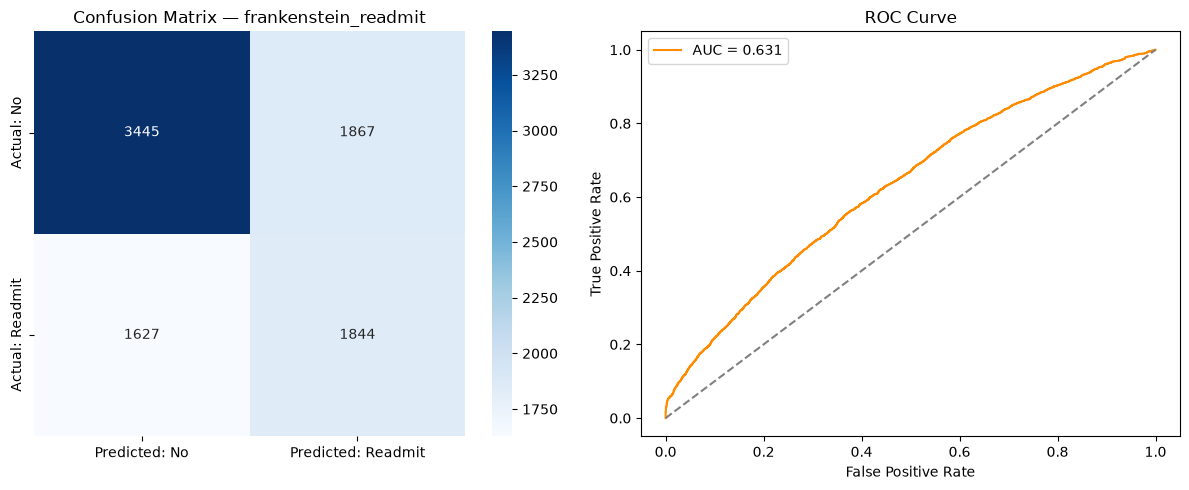

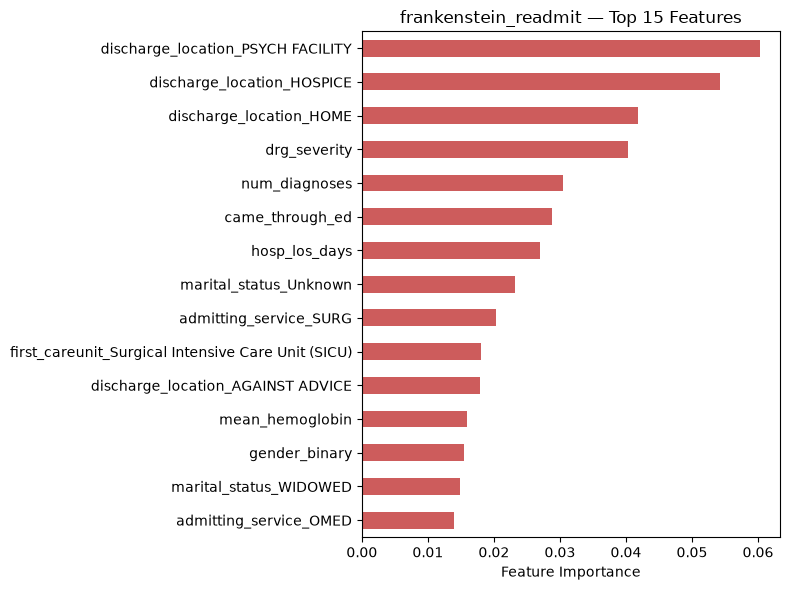


Top 15 features:
discharge_location_PSYCH FACILITY                     0.060314
discharge_location_HOSPICE                            0.054270
discharge_location_HOME                               0.041824
drg_severity                                          0.040312
num_diagnoses                                         0.030422
came_through_ed                                       0.028779
hosp_los_days                                         0.027043
marital_status_Unknown                                0.023257
admitting_service_SURG                                0.020258
first_careunit_Surgical Intensive Care Unit (SICU)    0.017985
discharge_location_AGAINST ADVICE                     0.017922
mean_hemoglobin                                       0.015864
gender_binary                                         0.015449
marital_status_WIDOWED                                0.014911
admitting_service_OMED                                0.013939
dtype: float32


In [28]:
import numpy as np
import xgboost as xgb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

# ============================================================
# 1. Drop rows with unknown target — can't train on a label we don't know
# ============================================================
df_readmit_clean = df_readmit.dropna(subset=['readmit_30d', 'los']).copy()
df_readmit_clean['readmit_30d'] = df_readmit_clean['readmit_30d'].astype(int)

# ============================================================
# 2. Drop leakage / redundant / ID columns
# ============================================================
drop_cols = [
    'subject_id', 'hadm_id', 'stay_id',       # IDs
    'intime', 'outtime',                       # raw timestamps, already summarized
    'last_careunit',                           # redundant with first_careunit
    'hospital_expire_flag',                    # LEAKAGE — died patients can't be readmitted
    'language',                                # excluded, same as race, pending Alexander discussion
]
df_readmit_clean = df_readmit_clean.drop(columns=drop_cols, errors='ignore')

# ============================================================
# 3. Handle remaining NaNs
# ============================================================
df_readmit_clean['ed_los_hours'] = df_readmit_clean['ed_los_hours'].fillna(0)

for col in ['discharge_location', 'insurance', 'marital_status', 'admitting_service']:
    df_readmit_clean[col] = df_readmit_clean[col].fillna('Unknown')

# ============================================================
# 4. Encode categoricals
# ============================================================
df_readmit_clean['gender_binary'] = (df_readmit_clean['gender'] == 'M').astype(int)
df_readmit_clean = df_readmit_clean.drop(columns=['gender'])

cat_cols = [
    'first_careunit', 'admission_type', 'admission_location',
    'discharge_location', 'insurance', 'marital_status', 'admitting_service'
]
df_readmit_clean = pd.get_dummies(df_readmit_clean, columns=cat_cols, drop_first=True)

print("df_readmit_clean shape:", df_readmit_clean.shape)
print("Remaining NaNs:", df_readmit_clean.isna().sum().sum())

# ============================================================
# 5. Patient-level train/test split
# ============================================================
X3 = df_readmit_clean.drop(columns=['readmit_30d'])
y3 = df_readmit_clean['readmit_30d']
groups3 = df_readmit.loc[df_readmit_clean.index, 'subject_id']

gss3 = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx3, test_idx3 = next(gss3.split(X3, y3, groups=groups3))

X3_train, X3_test = X3.iloc[train_idx3], X3.iloc[test_idx3]
y3_train, y3_test = y3.iloc[train_idx3], y3.iloc[test_idx3]

# ============================================================
# 6. Train frankenstein_readmit
# ============================================================
scale_pos_weight = (y3_train == 0).sum() / (y3_train == 1).sum()

frankenstein_readmit = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=scale_pos_weight, random_state=42
)
frankenstein_readmit.fit(X3_train, y3_train)

# ============================================================
# 7. Metrics
# ============================================================
y3_pred = frankenstein_readmit.predict(X3_test)
y3_prob = frankenstein_readmit.predict_proba(X3_test)[:, 1]

acc = accuracy_score(y3_test, y3_pred)
prec = precision_score(y3_test, y3_pred)
rec = recall_score(y3_test, y3_pred)
f1 = f1_score(y3_test, y3_pred)
auc = roc_auc_score(y3_test, y3_prob)
cm = confusion_matrix(y3_test, y3_pred)

print(f"\n=== frankenstein_readmit ===")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1:        {f1:.3f}")
print(f"AUC-ROC:   {auc:.3f}")
print("\nConfusion matrix:")
print(cm)

# ============================================================
# 8. Plot: confusion matrix + ROC
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No', 'Predicted: Readmit'],
    yticklabels=['Actual: No', 'Actual: Readmit'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix — frankenstein_readmit')

fpr, tpr, _ = roc_curve(y3_test, y3_prob)
axes[1].plot(fpr, tpr, color='darkorange', label=f'AUC = {auc:.3f}')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 9. Feature importance
# ============================================================
importances = pd.Series(frankenstein_readmit.feature_importances_, index=X3_train.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top_features.sort_values().plot(kind='barh', color='indianred')
plt.xlabel('Feature Importance')
plt.title('frankenstein_readmit — Top 15 Features')
plt.tight_layout()
plt.show()

print("\nTop 15 features:")
print(top_features)

In [29]:
from sklearn.utils import resample

train_df = X3_train.copy()
train_df['readmit_30d'] = y3_train.values

majority = train_df[train_df['readmit_30d'] == 0]
minority = train_df[train_df['readmit_30d'] == 1]

majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)
train_balanced = pd.concat([majority_downsampled, minority])

X3_train_bal = train_balanced.drop(columns=['readmit_30d'])
y3_train_bal = train_balanced['readmit_30d']

scale_pos_weight_bal = (y3_train_bal == 0).sum() / (y3_train_bal == 1).sum()

frankenstein_readmit_v2 = xgb.XGBClassifier(
    n_estimators=100, learning_rate=0.1, max_depth=5,
    scale_pos_weight=scale_pos_weight_bal, random_state=42
)
frankenstein_readmit_v2.fit(X3_train_bal, y3_train_bal)

y3_pred_v2 = frankenstein_readmit_v2.predict(X3_test)
y3_prob_v2 = frankenstein_readmit_v2.predict_proba(X3_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y3_test, y3_pred_v2):.3f}")
print(f"Precision: {precision_score(y3_test, y3_pred_v2):.3f}")
print(f"Recall:    {recall_score(y3_test, y3_pred_v2):.3f}")
print(f"F1:        {f1_score(y3_test, y3_pred_v2):.3f}")
print(f"AUC-ROC:   {roc_auc_score(y3_test, y3_prob_v2):.3f}")

Accuracy:  0.603
Precision: 0.497
Recall:    0.538
F1:        0.517
AUC-ROC:   0.631


In [30]:
import pickle as pkl
from pathlib import Path
import sys

CHECKPOINT_DIR = Path(r"E:\MedAgent\checkpoints")
CHECKPOINT_DIR.mkdir(exist_ok=True)  # in case it doesn't exist yet

# ============================================================
# Save dataframes
# ============================================================
with open(CHECKPOINT_DIR / "df_experiment.pkl", "wb") as f:
    pkl.dump(df_experiment, f)

with open(CHECKPOINT_DIR / "df_clean.pkl", "wb") as f:
    pkl.dump(df_clean, f)

# ============================================================
# Save models
# ============================================================
with open(CHECKPOINT_DIR / "frankenstein_los.pkl", "wb") as f:
    pkl.dump(frankenstein_los, f)

with open(CHECKPOINT_DIR / "model_extended_stay.pkl", "wb") as f:
    pkl.dump(model_extended_stay, f)

# ============================================================
# Save library versions used this session — so a reload later
# knows what environment produced these pickles
# ============================================================
import pandas as pd
import numpy as np
import xgboost as xgb
import sklearn
import matplotlib
import seaborn as sns

versions = {
    "python": sys.version,
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "xgboost": xgb.__version__,
    "scikit-learn": sklearn.__version__,
    "matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
}

with open(CHECKPOINT_DIR / "library_versions.pkl", "wb") as f:
    pkl.dump(versions, f)

print("Saved to", CHECKPOINT_DIR)
for name, ver in versions.items():
    print(f"  {name}: {ver}")

Saved to E:\MedAgent\checkpoints
  python: 3.13.14 | packaged by Anaconda, Inc. | (main, Jun 17 2026, 20:04:52) [MSC v.1942 64 bit (AMD64)]
  pandas: 3.0.3
  numpy: 2.4.6
  xgboost: 3.3.0
  scikit-learn: 1.9.0
  matplotlib: 3.11.0
  seaborn: 0.13.2


In [ ]:
# load next

import pickle as pkl
from pathlib import Path

CHECKPOINT_DIR = Path(r"E:\MedAgent\checkpoints")

with open(CHECKPOINT_DIR / "df_experiment.pkl", "rb") as f:
    df_experiment = pkl.load(f)

with open(CHECKPOINT_DIR / "df_clean.pkl", "rb") as f:
    df_clean = pkl.load(f)

with open(CHECKPOINT_DIR / "frankenstein_los.pkl", "rb") as f:
    frankenstein_los = pkl.load(f)

with open(CHECKPOINT_DIR / "model_extended_stay.pkl", "rb") as f:
    model_extended_stay = pkl.load(f)

with open(CHECKPOINT_DIR / "library_versions.pkl", "rb") as f:
    versions = pkl.load(f)

print("Loaded. Session was built with:", versions)